# Lesson 2

This is an interactive notebook on data analysis. We will cover the Titanic data set, tips data set and web scraping.

You need to install `Numpy`, `Pandas`, `seaborn` packages in order to run the notebook.


The materials for this set of lessons are from many sources and draws heavily from:\
https://pandas.pydata.org/docs/user_guide/index.html#user-guide \
https://seaborn.pydata.org/index.html \
https://jakevdp.github.io/PythonDataScienceHandbook/ \
https://www.programmer-books.com/wp-content/uploads/2019/04/Python-for-Data-Analysis-2nd-Edition.pdf


All course materials, including all lecture notes and python notebooks, are for your own educational purposes only. All the contents of the materials are protected by copyright, trademark or other forms of proprietary rights.
All rights, title and interest in the materials are owned by, licensed to or controlled by the University (i.e., Nanyang Technological University), unless otherwise expressly stated. The materials shall not be uploaded, reproduced, distributed, republished or transmitted in any form or by any means, in whole or in part, without written approval from the University.


---
# Titanic Dataset

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

We will analyze the dataset to learn more this tragic event.

---

In [1]:
# import the packages needed
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
import timeit

# change resolution
plt.rcParams['figure.dpi'] = 150 

In [2]:
# Load dataset
titanic = sb.load_dataset('titanic')

## Descriptive Statistics

In [3]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [5]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


This contains a wealth of information on each passenger of that ill-fated voyage, including gender, age, class, fare paid, and much more.

---
### Accessing and setting data


In [8]:
# Returns a Series of name '4', and the age and fare values

titanic.loc[4, ['age', 'fare']]

age     35.0
fare    8.05
Name: 4, dtype: object

In [9]:
# Returns a DataFrame with rows 4 and 5, and columns 'age' and 'fare'

titanic.loc[[4, 5], ['age', 'fare']]

,age,fare
4,35.0,8.0500
5,NaN,8.4583


Use a boolean query to get a subset of the data.

This  query has four True/False series (query terms) combined with the & (element to element) operator.

The first Series was constructed using the titanic.sex Series (['female', 'male', 'female'...]) and comparing each value to the 'female' string, returning True/False for each value.

The second Series used the `pandas.Series.isin` function (which is pretty straightforward), and also accesses the series using square brackets for a reason; "class" is a reserved word in Python for defining classes, and using it with the dot notation raises a SyntaxError exception.

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isin.html

The third and fourth "terms" work just like the first one.

In [10]:
titanic[
    (titanic.sex == 'female')
    & (titanic['class'].isin(['First', 'Third']))
    & (titanic.age > 30)
    & (titanic.survived == 0)
]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
18,0,3,female,31.0,1,0,18.0000,S,Third,woman,False,NaN,Southampton,no,False
40,0,3,female,40.0,1,0,9.4750,S,Third,woman,False,NaN,Southampton,no,False
132,0,3,female,47.0,1,0,14.5000,S,Third,woman,False,NaN,Southampton,no,False
167,0,3,female,45.0,1,4,27.9000,S,Third,woman,False,NaN,Southampton,no,False
177,0,1,female,50.0,0,0,28.7125,C,First,woman,False,C,Cherbourg,no,True
254,0,3,female,41.0,0,2,20.2125,S,Third,woman,False,NaN,Southampton,no,False
276,0,3,female,45.0,0,0,7.7500,S,Third,woman,False,NaN,Southampton,no,True
362,0,3,female,45.0,0,1,14.4542,C,Third,woman,False,NaN,Cherbourg,no,False
396,0,3,female,31.0,0,0,7.8542,S,Third,woman,False,NaN,Southampton,no,True
503,0,3,female,37.0,0,0,9.5875,S,Third,woman,False,NaN,Southampton,no,True


How many male/female passengers on board the titanic?

In [11]:
sum(titanic.sex == 'female')

314

In [12]:
sum(titanic.sex == 'male')

577

---
### GroupBy

Suppose we want to classify each titanic passenger by their age. 

Firstly we define the bins, i.e. the values that will delimit the age intervals we want.

Secondly, we define the labels, i.e. the name of each bin/interval

Thirdly, we use `pandas.cut` to map the titanic's passengers ages to a label.

Finally, we set the result Series from the last step as a new column in our titanic DataFrame

Now, we can use the newly created "age_group" column to group by the titanic passengers.

Use `pandas.cut` when you need to segment and sort data values into bins. This function is also useful for going from a continuous variable to a categorical variable. For example, cut could convert ages to groups of age ranges. Supports binning into an equal number of bins, or a pre-specified array of bins.

https://pandas.pydata.org/docs/reference/api/pandas.cut.html


In [13]:
bins = [0, 12, 17, 60, np.inf]
labels = ['child', 'teenager', 'adult', 'elder']
age_groups = pd.cut(titanic.age, bins, labels=labels)
titanic['age_group'] = age_groups

In [14]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,adult


A `groupby` operation involves some combination of splitting the object, applying a function, and combining the results. This can be used to group large amounts of data and compute operations on these groups.

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html

"groups" is an object of type DataFrameGroupBy. It can be iterated in order to inspect or work with the different groups (each one a DataFrame object) You can also use the get_group method (in this case passing it a 2-sized tuple) to get the corresponding DataFrame group.

In [15]:
titanic.groupby('sex')[['survived']].mean()

,survived
sex,
female,0.742038
male,0.188908


This immediately gives us some insight: overall, three of every four females on board survived, while only one in five males survived! 

Widener library at Harvard built in memory of a victim of Titanic:

https://en.wikipedia.org/wiki/Harry_Elkins_Widener

https://en.wikipedia.org/wiki/Widener_Library

This is useful, but we might like to go one step deeper and look at survival by both sex and, say, class. Using the vocabulary of `GroupBy`, we might proceed using something like this: we group by class and gender, select survival, apply a mean aggregate, combine the resulting groups, and then unstack the hierarchical index to reveal the hidden multidimensionality. In code:

In [16]:
groups = titanic.groupby(['age_group', 'alone'])

In [17]:
groups.size()

age_group  alone
child      False     67
           True       2
teenager   False     23
           True      21
adult      False    216
           True     363
elder      False      4
           True      18
dtype: int64

Since this result is a Series, we can easily get the size of each group in relation to the whole dataset.

In [18]:
100 * groups.size() / len(titanic)

age_group  alone
child      False     7.519641
           True      0.224467
teenager   False     2.581369
           True      2.356902
adult      False    24.242424
           True     40.740741
elder      False     0.448934
           True      2.020202
dtype: float64

Now we can see very easily that, for example, most children did not travel alone.

---
### Calculated columns


When you're working with Pandas, there is something you most certainly will want to do, and that is adding a column with calculated values to your DataFrame.

A general approach is to use the `apply` function. 

If we wanted to add a column "is_old" with boolean values, for every row (passenger) of the titanic, we should do the following:



In [19]:
def is_old_func(row):
    return row['age'] > 60
titanic['is_old'] = titanic.apply(is_old_func, axis='columns')


What we did there was to create a Series by applying a custom function to each row of the DataFrame. Then we assigned the series to a new column named "is_old" in the titanic DataFrame.

Notice how we use the `axis` argument in the `DataFrame.apply` invocation. A good way to remember how to use this argument is the following:

- `axis='columns'` makes the custom function receive a Series with one value per column (i.e. a row) in each invocation.
- `axis='rows'` makes the custom function receive a Series with one value per row (i.e. a column) in each invocation.

This approach is good if we need to use multiple values of a row. But in this case, we only use the "age" value of every row. So, in this case, it would seem unnecessary to use apply for the whole DataFrame.

In [20]:
def is_old_func_series(value):
    return value > 60
titanic['is_old'] = titanic.age.apply(is_old_func_series)

Series.apply does not receive an axis argument since Series have only one axis.

We defined a new is_old_func_series custom function since Series.apply passes scalars (the Series values) to the custom function, and trying to access the attribute "age" of a scalar would raise an AttributeError exception.

This approach seems to just use the necessary data for the calculation, and as we'll see it is orders of magnitude faster.

In [21]:
%timeit -n1000 titanic['is_old'] = titanic.apply(is_old_func, axis='columns')
%timeit -n1000 titanic['is_old'] = titanic.age.apply(is_old_func_series)

1.7 ms ± 112 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
131 µs ± 9.24 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In the presence of "a lot" of rows (more than 10.000) and simple calculations for the new column, there's an alternative whose execution time is orders of magnitude lower than `Series.apply`. This alternative is the `eval` method.

`eval` is extremely fast in this case, because it performs arithmetic and boolean expression evaluations "all at once" using the underlying engine `numexpr`, which is a high performance numerical evaluator for NumPy.

Its syntax is a little more friendly than that of apply, but for now does not support if operations. To do assignments to a subset of the DataFrame you could use a combination of loc/iloc and eval.

In [22]:
titanic.eval('is_old = age > 60', inplace=True)

In [23]:
titanic.head() # we have modified the dataframe since 'inplace=True'

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group,is_old
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,adult,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,adult,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,adult,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,adult,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,adult,False


In [24]:
sum(titanic.is_old == True)

22

In all, there were 22 old person (age > 60).

---
### Reshaping

Reshaping is, broadly speaking transforming the structure of the data to make it suitable for further analysis. In the context of Pandas, we can reshape a DataFrame by using one column's values as the index, and another column's values as new columns, this is called pivoting.


---
### Pivoting

There are two main ways to apply pivoting in Pandas, the `pivot` and `pivot_table` methods.

The `pivot` function is more restrictive than `pivot_table` since it needs the DataFrame's column set as "index" to have unique values only.

Our data doesn't fit the pivot input quite properly, which is "stacked" or "record" formatted data (as indicated in the Pandas docs), but for the sake of demonstrating its usage, we'll tweak our titanic DataFrame a little bit.



In [25]:
p_titanic = titanic.drop_duplicates('age').pivot(index='age', columns='class', values='fare')
p_titanic.tail(3)

class,First,Second,Third
age,,,
71.0,34.6542,NaN,NaN
74.0,NaN,NaN,7.775
80.0,30.0000,NaN,NaN


We first removed all rows with duplicated "age" values (keeping the first appearance of each one) and pivoted that DataFrame. The index of that new DataFrame are the labels in the "age" column (all unique now), the columns of the new DataFrame are the unique labels of the "class" column in the original DataFrame, and the values are the corresponding "fare" values.

`drop_duplicates()` return DataFrame with duplicate rows removed.
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html


---
### Pivot_table

A better alternative for this is to use the `pivot_table` method, since it saves us from having to drop duplicates (which in this case makes no sense), and it aggregates the DataFrame values (by default performs an average).

In [26]:
pt_titanic = titanic.pivot_table(index='age', columns='class', values='fare')
pt_titanic.tail(3)

class,First,Second,Third
age,,,
71.0,42.0792,NaN,NaN
74.0,NaN,NaN,7.775
80.0,30.0000,NaN,NaN


In the pivot example we have only one row with "age" == 71 and "class" == "First", therefore the value ( 34.6542 ) is the "fare" value of that row. Whilst in the pivot_table example, we have several rows with "age" == 71 and "class" == "First", and the value ( 42.0792 ) is the average of the "fare" values of those rows.

Something cool we could calculate, for example, is the median of the paid fares per embarking town, per age group. We can do this easily with pivot_table in one line. We need to indicate that the aggregating function to be used is np.median.


In [27]:
titanic.pivot_table(index='embark_town', columns='age_group', values='fare', aggfunc=np.median)

age_group,child,teenager,adult,elder
embark_town,,,,
Cherbourg,18.7875,14.4542,49.5042,49.5042
Queenstown,29.1250,7.7500,7.7500,7.7500
Southampton,27.9000,14.2500,13.0000,26.5500


---
Suppose we are interested in finding the survival rate of the passengers based on class and sex.

In [28]:
titanic.groupby(['sex', 'class'])['survived'].aggregate('mean')

sex     class 
female  First     0.968085
        Second    0.921053
        Third     0.500000
male    First     0.368852
        Second    0.157407
        Third     0.135447
Name: survived, dtype: float64

In [29]:
titanic.groupby(['sex', 'class'])['survived'].aggregate('mean').unstack()

class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


This gives us a better idea of how both gender and class affected survival, but the code is starting to look a bit garbled. While each step of this pipeline makes sense in light of the tools we’ve previously discussed, the long string of code is not particularly easy to read or use. 

We can use `pivot_table` instead, which succinctly handles this type of multidimensional aggregation.


Here is the equivalent to the preceding operation using the pivot_table method of DataFrames:

In [30]:
titanic.pivot_table(index='sex', columns='class', values='survived', aggfunc=np.mean)

class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


This is eminently more readable than the `GroupBy` approach, and produces the same result. As you might expect of an early 20th-century transatlantic cruise, the survival gradient favors both women and higher classes. First-class women survived with near certainty (hi, Rose!), while only one in ten third-class men survived (sorry, Jack!).

Actually, in this case, we can write it simply as:

In [31]:
titanic.pivot_table('survived', index='sex', columns='class')

class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


---
### Multilevel pivot tables

Just as in the GroupBy, the grouping in pivot tables can be specified with multiple levels, and via a number of options. For example, we might be interested in looking at age as a third dimension. We’ll bin the age using the pd.cut function:

In [32]:
bins= [0, 18, 80]
age = pd.cut(titanic['age'], bins)

In [33]:
titanic.pivot_table('survived', ['sex', age], 'class')

class               First    Second     Third
sex    age                                   
female (0, 18]   0.909091  1.000000  0.511628
       (18, 80]  0.972973  0.900000  0.423729
male   (0, 18]   0.800000  0.600000  0.215686
       (18, 80]  0.375000  0.071429  0.133663

We can apply this same strategy when working with the columns as well; let’s add info on the fare paid using `pd.qcut` to automatically compute quantiles:

https://pandas.pydata.org/docs/reference/api/pandas.qcut.html

In [34]:
fare = pd.qcut(titanic['fare'], 2)
titanic.pivot_table('survived', ['sex', age], [fare, 'class'])

fare            (-0.001, 14.454]                     (14.454, 512.329]  \
class                      First    Second     Third             First   
sex    age                                                               
female (0, 18]               NaN  1.000000  0.714286          0.909091   
       (18, 80]              NaN  0.880000  0.444444          0.972973   
male   (0, 18]               NaN  0.000000  0.260870          0.800000   
       (18, 80]              0.0  0.098039  0.125000          0.391304   

fare                                 
class              Second     Third  
sex    age                           
female (0, 18]   1.000000  0.318182  
       (18, 80]  0.914286  0.391304  
male   (0, 18]   0.818182  0.178571  
       (18, 80]  0.030303  0.192308

The result is a four-dimensional aggregation with hierarchical indices, shown in a grid demonstrating the relationship between the values.

---
### Additional pivot table options

In the `DataFrame.pivot_table`, the aggregation specification can be a string representing one of several common choices ('sum', 'mean', 'count', 'min', 'max', etc.) or a function that implements an aggregation (np.sum(), min(), sum(), etc.). Additionally, it can be specified as a dictionary mapping a column to any of the above desired options.

`aggfunc`

If list of functions passed, the resulting pivot table will have hierarchical columns whose top level are the function names (inferred from the function objects themselves) If dict is passed, the key is column to aggregate and value is function or list of functions.

In [35]:
titanic.pivot_table(index='sex', columns='class',aggfunc={'survived':sum, 'fare':'mean'})

fare                       survived             
class        First     Second      Third    First Second Third
sex                                                           
female  106.125798  21.970121  16.118810       91     70    72
male     67.226127  19.741782  12.661633       45     17    47

Notice also here that we’ve omitted the `values` keyword; when you’re specifying a mapping for `aggfunc`, this is determined automatically.

In [36]:
titanic.pivot_table('survived', index='sex', columns='class', margins=True)

class,First,Second,Third,All
sex,,,,
female,0.968085,0.921053,0.500000,0.742038
male,0.368852,0.157407,0.135447,0.188908
All,0.629630,0.472826,0.242363,0.383838


Here this automatically gives us information about the class-agnostic survival rate by gender, the gender-agnostic survival rate by class, and the overall survival rate of 38%. The `margin` label can be specified with the margins_name keyword, which defaults to "All". 

`margins` -  bool, default False

Add all row / columns (e.g. for subtotal / grand totals).

---
### Melt
The inverse process of pivoting, unpivoting we might call it, is implemented in Pandas by the `pandas.melt` function.

This function takes a DataFrame and "melts it", that is, it takes one or more columns and uses them as "indentifier variables" (keeps them the way they are). The rest of the columns are "converted" into two "unidentifier (or measured) variable" columns "variable" and "value".



In [37]:
p_titanic_copy = p_titanic.copy()
p_titanic_copy.columns = p_titanic_copy.columns.astype(str)
pd.melt(
    p_titanic_copy.reset_index(),
    id_vars='age',
    var_name='class_renamed',
    value_vars=['First', 'Second', 'Third'],
    value_name='fare'
).tail(3)

,age,class_renamed,fare
264,71.0,Third,NaN
265,74.0,Third,7.775
266,80.0,Third,NaN


In the example:

- `p_titanic.reset_index()`: We do this because p_titanic does not have a column named "age" with the age values, but an index named "age" with the age values, and for the unpivoting process we're going to want to have the "age" column.
- `id_vars='age'`: This indicates that our "identifying variable" is going to be the column "age" (we can have more than one identifying variable/column when melting)
- `var_name`: This argument simply sets the name for the "variable" column. We want it to be named "class_renamed". If None, the p_titanic.reset_index().columns.name ("class" in this case) value is used, and if that's not set, the column will just be named "variable".
- `value_vars`: These are the columns that are going to be "unpivoted" to the rows axis, and are going to be values of the "variable" column. If not set, the method considers all non-identifying variable columns.
- `value_name`: This simply sets the name for the "value" column. We want it to be named "fare". If None, the name "value" is used.

---
### Stacking

We can also reshape a DataFrame by stacking/unstacking. This is related to Hierarchical indexes or MultiIndexes, which are a way to represent higher (than 1 or 2) dimensional data in Series or DataFrames.

If you recall the `groupby` snippet where we called `DataFrameGroupBy.size`, the result of that invocation was a Series with a MultiIndex with two levels, the first one (level 0) corresponding to the "age_group", and the second one (level 1) corresponding to the "alone" flag.

You can see how MultiIndexes work very easily, simply by removing the values argument in the pivot/pivot_table examples. This will create a DataFrame with MultiIndexed columns with two levels; the first one being the value ("fare", "age", "survived", etc.) and the second one, the "age_group". Therefore, you can get an equivalent result with the following line:

In [38]:
titanic.pivot_table(index='embark_town', columns='age_group', values='fare', aggfunc=np.mean)

age_group,child,teenager,adult,elder
embark_town,,,,
Cherbourg,19.937127,31.027254,78.735722,48.712533
Queenstown,29.125000,7.837500,18.733116,7.750000
Southampton,34.077776,33.038396,25.851003,41.783069


But back to the point, stacking and unstacking. Stacking is to take a level of the columns index and transfer it to the rows index. Therefore, unstacking is the opposite; transferring a level from the rows level to the columns level.

This works even with DataFrames with single level axes. Stacking or unstacking a DataFrame of this characteristics would turn it into a MultiIndex Series!

We can take the MultiIndex Series from the groupby snippet mentioned earlier, and unstack any of its levels.



In [39]:
groups = titanic.groupby(['age_group', 'alone'])
groups.size()

age_group  alone
child      False     67
           True       2
teenager   False     23
           True      21
adult      False    216
           True     363
elder      False      4
           True      18
dtype: int64

In [40]:
groups.size().unstack()

alone,False,True
age_group,,
child,67,2
teenager,23,21
adult,216,363
elder,4,18


By default, stack/unstack takes the highest level, in this case the level 1, but we could e.g. unstack the level 0. You can try running stack on the results of these examples to see it in action.


In [41]:
groups.size().unstack(level=0)

age_group,child,teenager,adult,elder
alone,,,,
False,67,23,216,4
True,2,21,363,18


---
## Data visualization

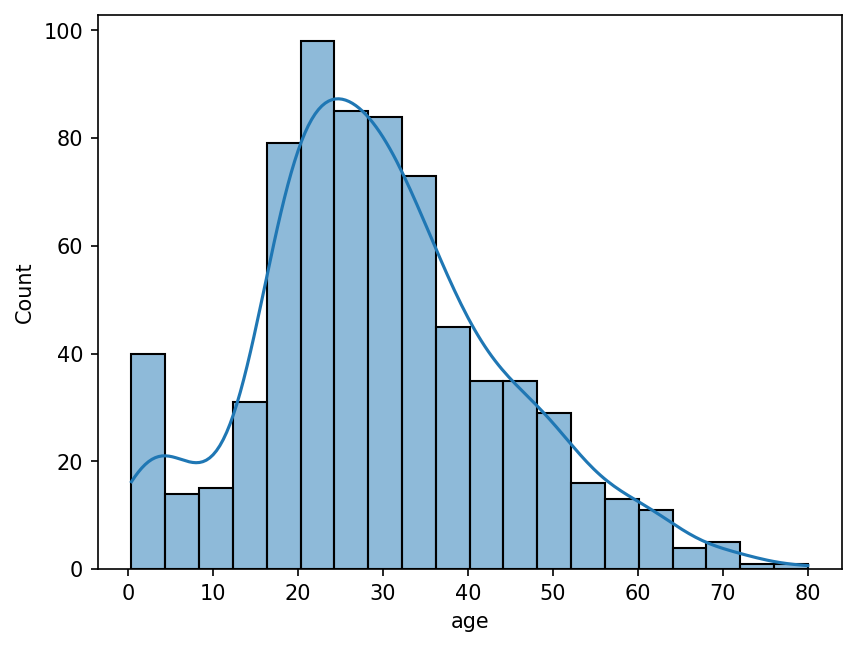

In [42]:
import seaborn as sb

sb.histplot(titanic.age, kde=True)
plt.show()

---
### FacetGrid 

https://seaborn.pydata.org/generated/seaborn.FacetGrid.html

If we wanted to break down a plot (e.g. the last one) by some categories, we needn't perform boolean queries, nor groupbys, we can use `FacetGrid`.

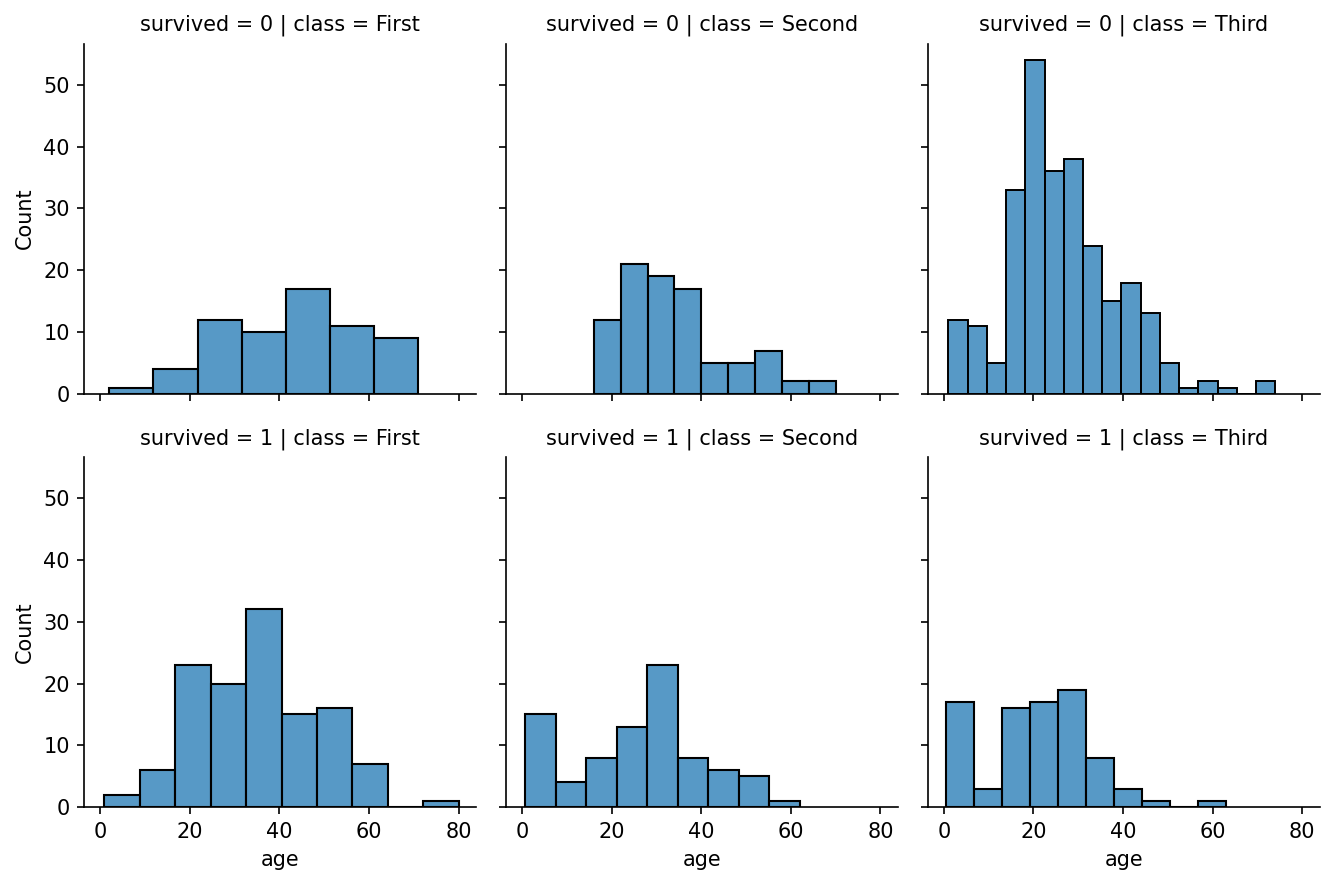

In [43]:
g = sb.FacetGrid(titanic, row='survived', col='class')
g.map(sb.histplot, "age")
plt.show()

---
### Jointplot

https://seaborn.pydata.org/generated/seaborn.jointplot.html

This method is used to display data points according to two variables, along with both their distributions, kernel density estimators, and an optional regression that fits the data. With reg we indicate that we want a regression fit to the data.

-In this case, although there appears to be a small tendency upwards shown by the regression, almost no correlation between the variables "age" and "fare" seems to exist, as shown by the Pearson correlation coefficient.

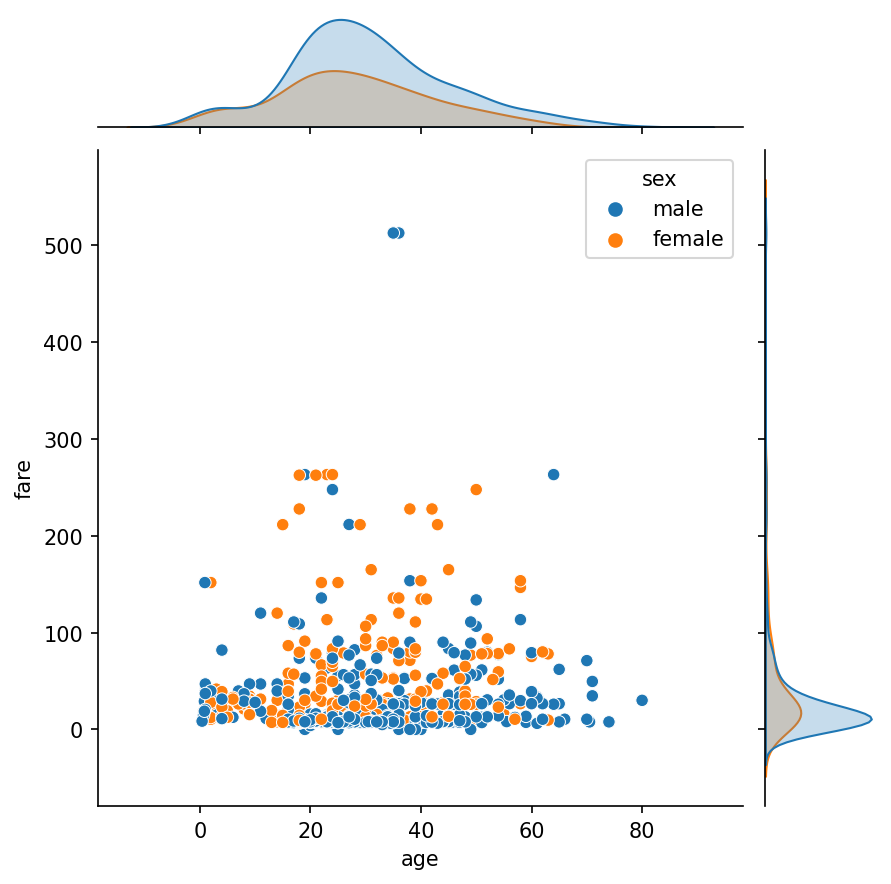

In [44]:
sb.jointplot(data=titanic, x='age', y='fare', kind='scatter', hue='sex')
plt.show()

---
### catplot

https://seaborn.pydata.org/generated/seaborn.catplot.html

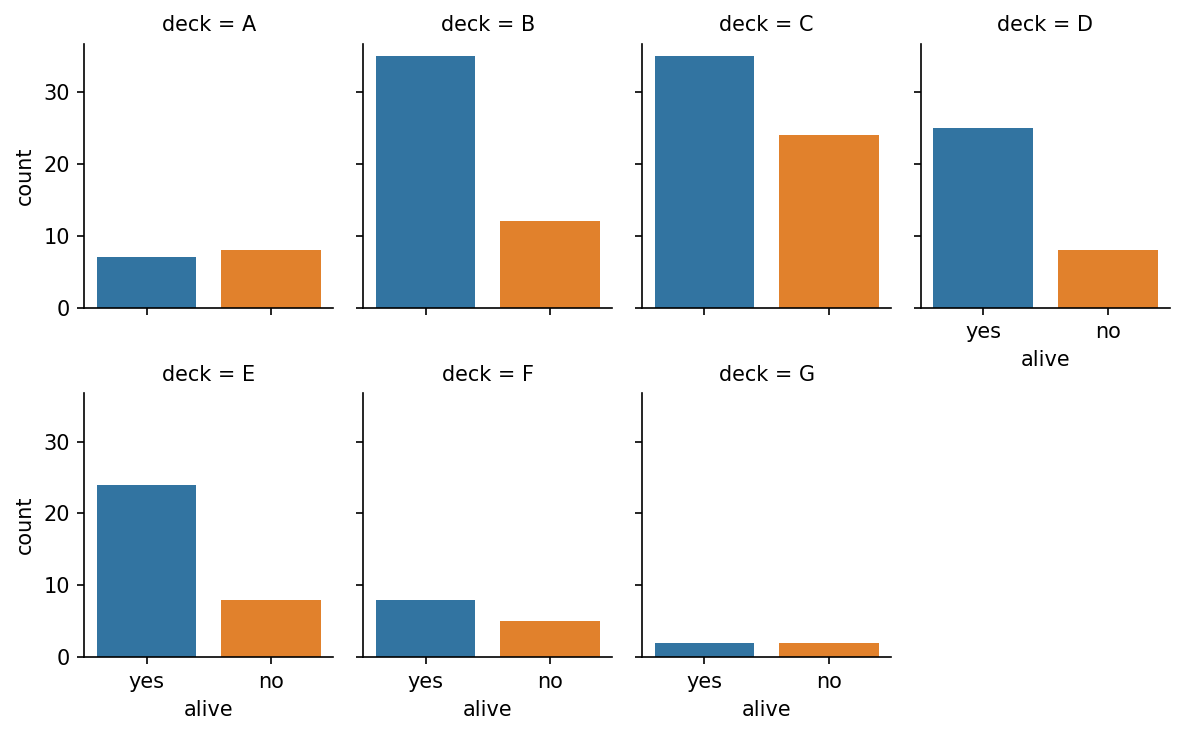

In [45]:
# need to take care of NaN data in titanic.deck

sb.catplot(x="alive", col="deck", col_wrap=4,
                data=titanic[titanic.deck.notnull()],
                kind="count", height=2.5, aspect=.8)

In [46]:
titanic[titanic.deck.notnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group,is_old
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,adult,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,adult,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True,adult,False
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False,child,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True,adult,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False,adult,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True,adult,False
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False,adult,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,adult,False


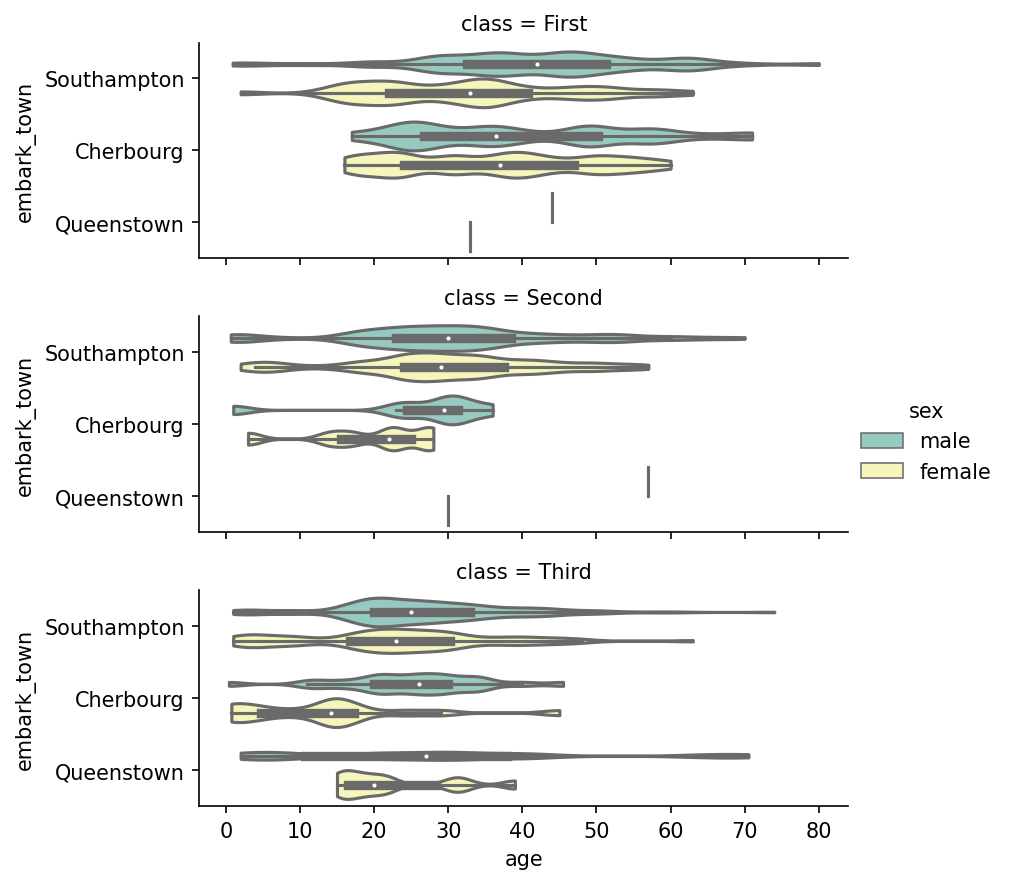

In [47]:
sb.catplot(x="age", y="embark_town",
                hue="sex", row="class",
                data=titanic[titanic.embark_town.notnull()],
                orient="h", height=2, aspect=3, palette="Set3",
                kind="violin", dodge=True, cut=0, bw=.2)


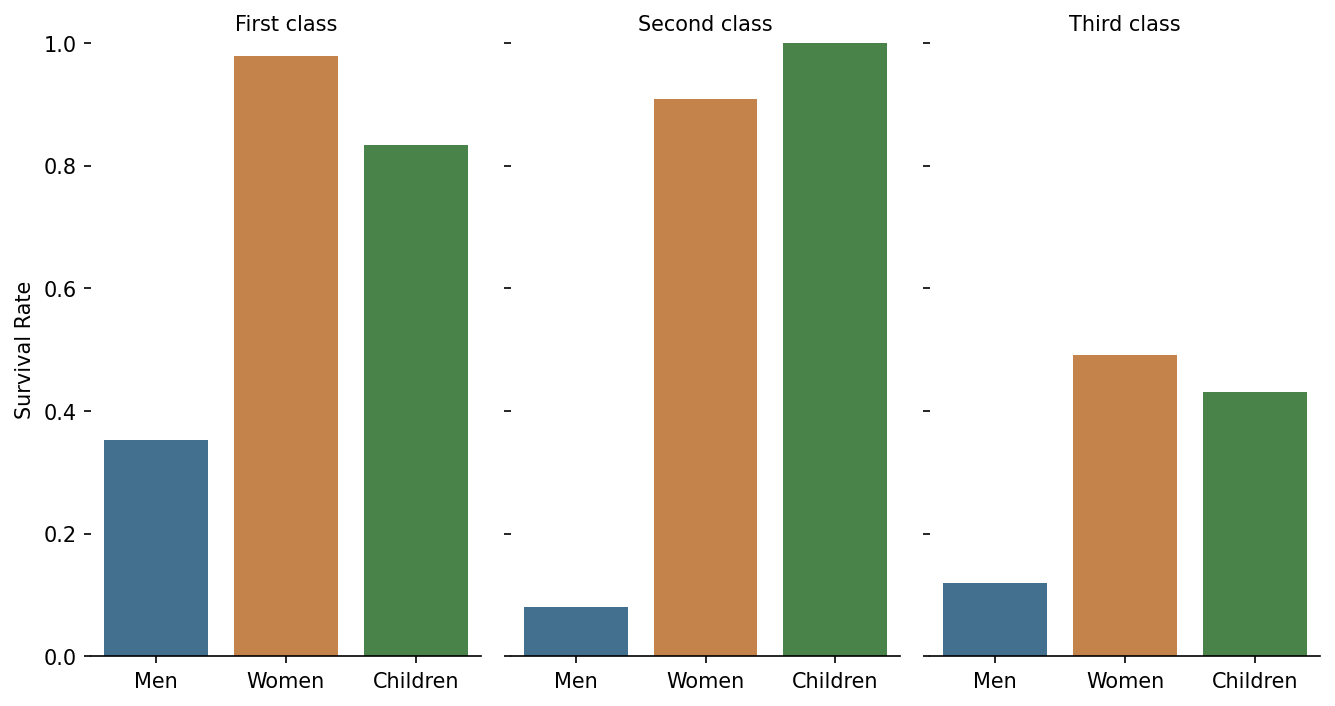

In [48]:
g = sb.catplot(x="who", y="survived", col="class",
                data=titanic, saturation=.5,
                kind="bar", errorbar=None, aspect=.6)
(g.set_axis_labels("", "Survival Rate")
  .set_xticklabels(["Men", "Women", "Children"])
  .set_titles("{col_name} {col_var}")
  .set(ylim=(0, 1))
  .despine(left=True))  

---
### Heatmap



`Heatmaps` are ideal to plot "rectangular data" such as matrices. They're great to visualize when some values, or calculated values, such as averages, counts, etc. are more extreme.

https://seaborn.pydata.org/generated/seaborn.heatmap.html

We can take the pt_titanic DataFrame from the pivot_table, which held data of the median fares paid by passengers per embark_town per age_group, and build a heatmap very easily. Most times, we like out heatmaps annotated to catch some subtleties that may pass by me with the colors. The fmt value is pretty straightforward.


In [49]:
df = titanic.pivot_table(index='embark_town', columns='age_group', values='fare', aggfunc=np.median)
df

age_group,child,teenager,adult,elder
embark_town,,,,
Cherbourg,18.7875,14.4542,49.5042,49.5042
Queenstown,29.1250,7.7500,7.7500,7.7500
Southampton,27.9000,14.2500,13.0000,26.5500


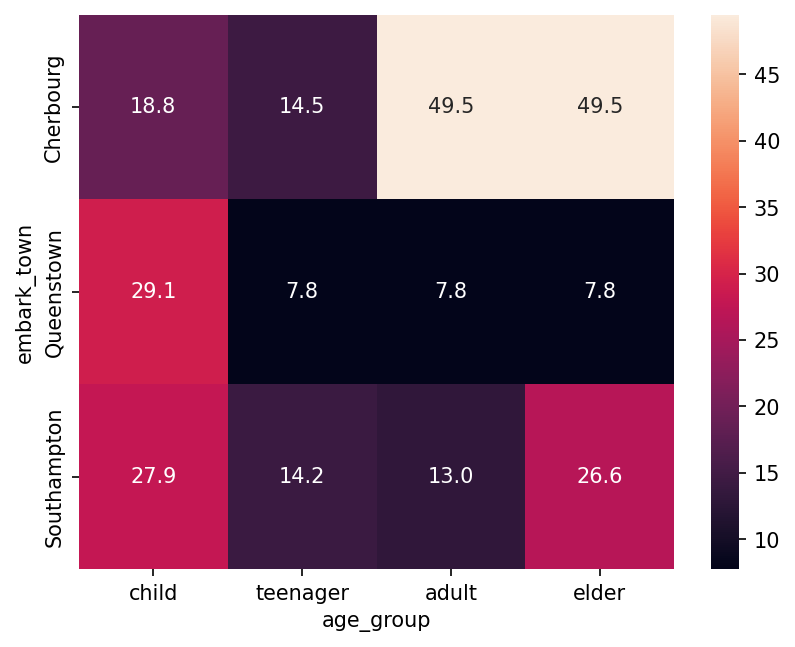

In [50]:
sb.heatmap(df, annot=True, fmt=".1f")
plt.show()

Finally, something really cool that you can put into a heatmap is a correlation matrix. Pandas DataFrame has a corr method that calculates Pearson's (can be another) correlation coefficient between all couples of numeric columns of the DataFrame.

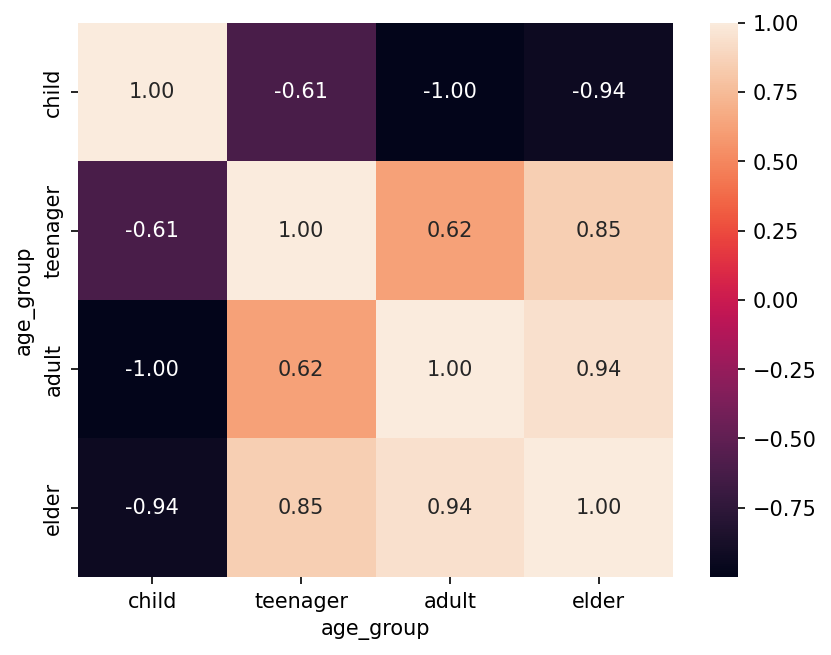

In [51]:
sb.heatmap(df.corr(), annot=True, fmt=".2f")
plt.show()

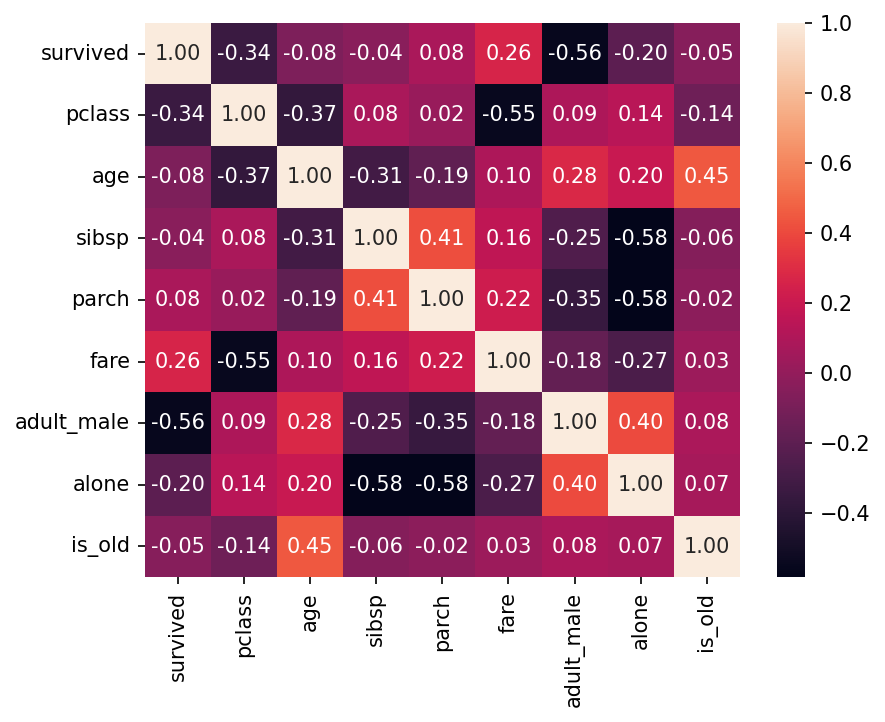

In [52]:
sb.heatmap(titanic.corr(numeric_only = True), annot=True, fmt=".2f")
plt.show()

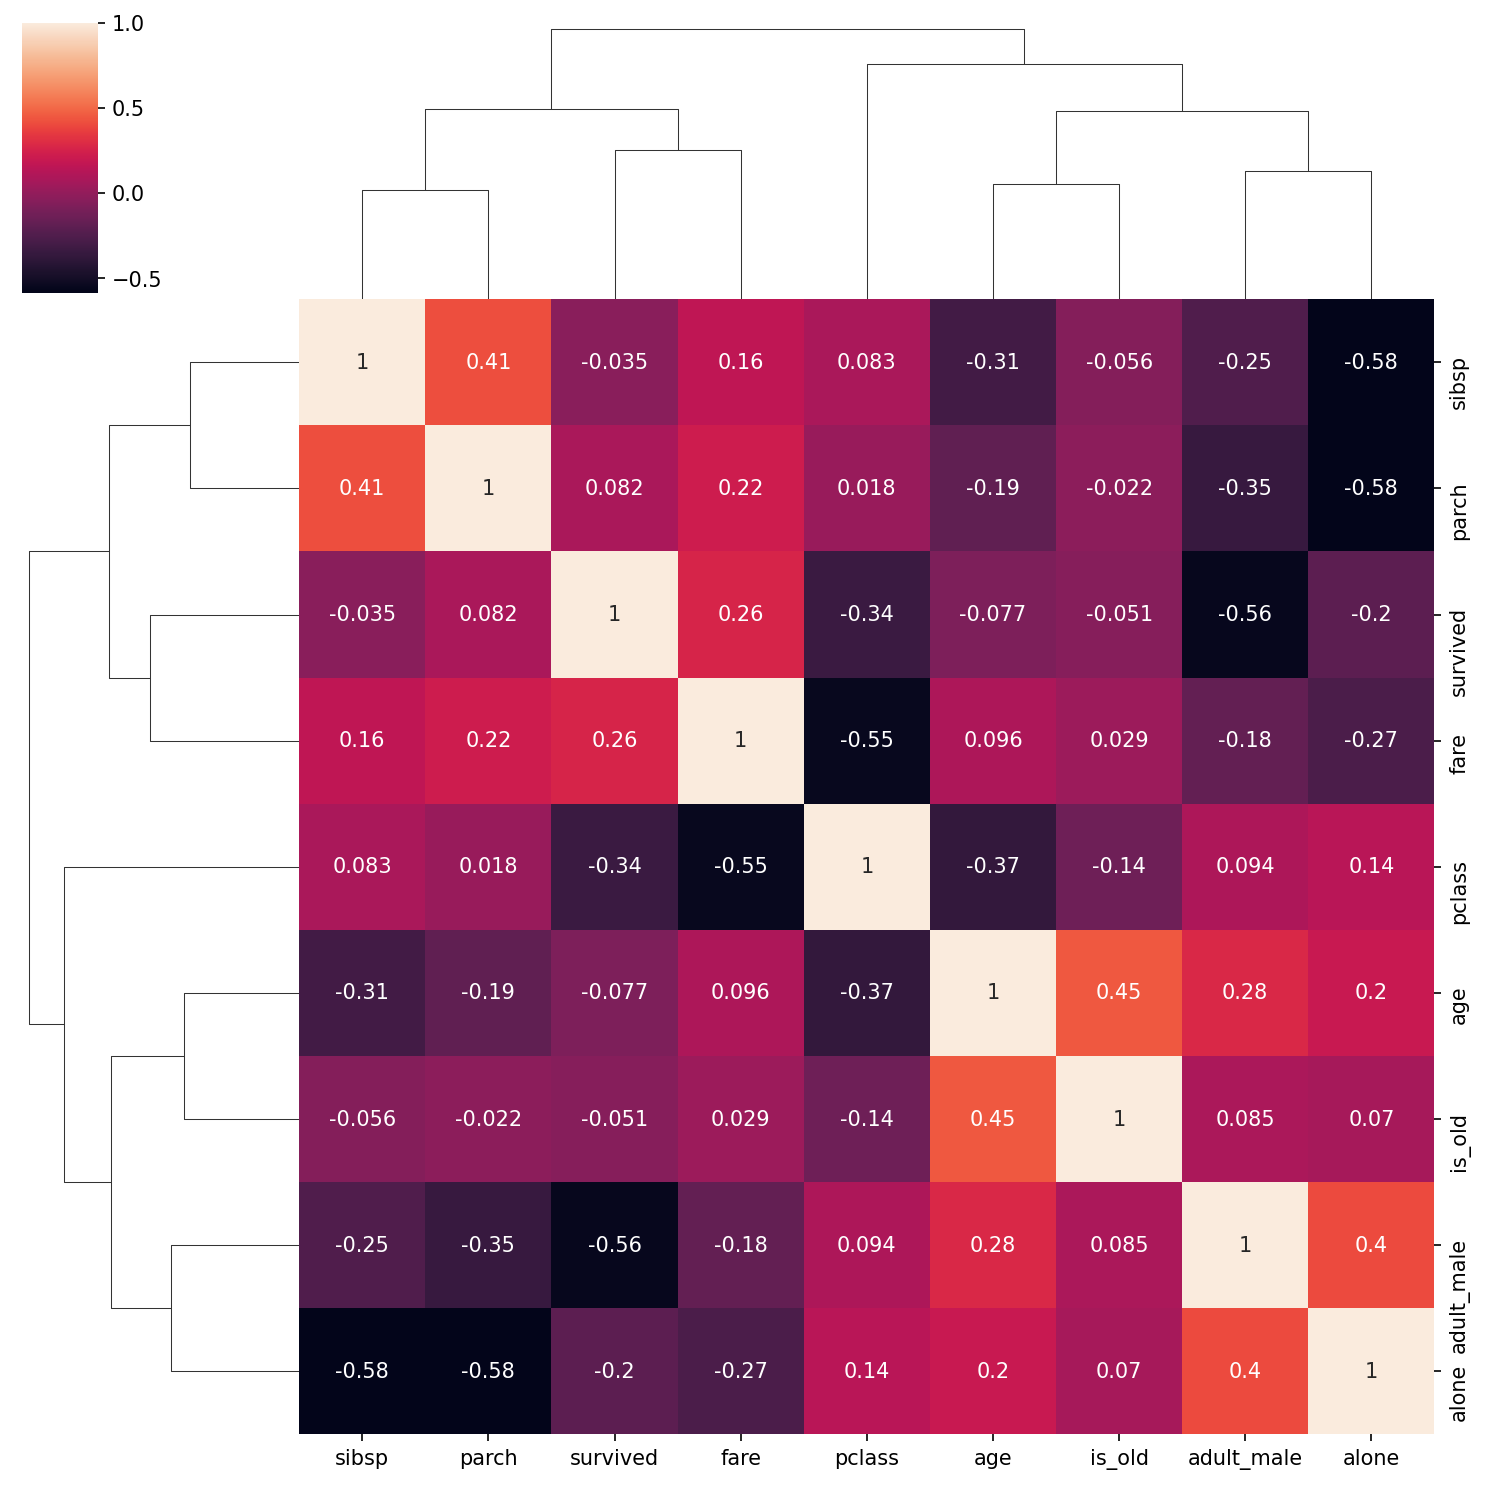

In [53]:
corr_titanic = titanic.corr(method='pearson', numeric_only = True)

fig = sb.clustermap(corr_titanic, 
                    annot=True,
               row_cluster=True,
               col_cluster=True,
               figsize=(10, 10));

---
## Tasks

- Read the first 10 records of titanic
- Find the number of male and female survivors using `groupby()`
- Find the mean price of fare for female passengers embarking from Southampton and Cherbourg. `pivot_table` will be useful here.
- Find the mean price of 3rd class tickets for male passengers embarking from Queenstown and Cherbourg. `pivot_table` will be useful here.
- Do a multi-figure histplot using `FacetGrid()` illustrating the distribution of fare prices as a function of (row=)sex and (col=)class.
- Find the mean age of male and female adult (age bracket 17-60) survivors. `pivot_table` will be useful here.
- How many aged female passenger (age bracket > 60) survived the titanic? How many didn't? Use boolean array.
- How many aged male passenger (age bracket > 60) survived the titanic? How many didn't? Use boolean array.
- Produce a table showing the number of survivors of the titanic partitioned by sex, is_old, and pclass.

In [54]:
titanic.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group,is_old
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,adult,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,adult,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,adult,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,adult,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,adult,False
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True,NaN,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True,adult,False
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False,child,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False,adult,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False,teenager,False


In [55]:
titanic.groupby('sex')[['survived']].sum()

,survived
sex,
female,233
male,109


In [56]:
titanic.groupby('sex')[['survived']].mean()

,survived
sex,
female,0.742038
male,0.188908


In [57]:
titanic.pivot_table(values= 'fare',index='embark_town', columns='sex', aggfunc=np.mean)

sex,female,male
embark_town,,
Cherbourg,75.169805,48.262109
Queenstown,12.634958,13.838922
Southampton,38.740929,21.711996


In [58]:
titanic.pivot_table('fare','embark_town', ['sex', 'class'], aggfunc=np.mean)

sex              female                             male                      
class             First     Second      Third      First     Second      Third
embark_town                                                                   
Cherbourg    115.640309  25.268457  14.694926  93.536707  25.421250   9.352237
Queenstown    90.000000  12.350000  10.307833  90.000000  12.350000  11.924251
Southampton   99.026910  21.912687  18.670077  52.949947  19.232474  13.307149

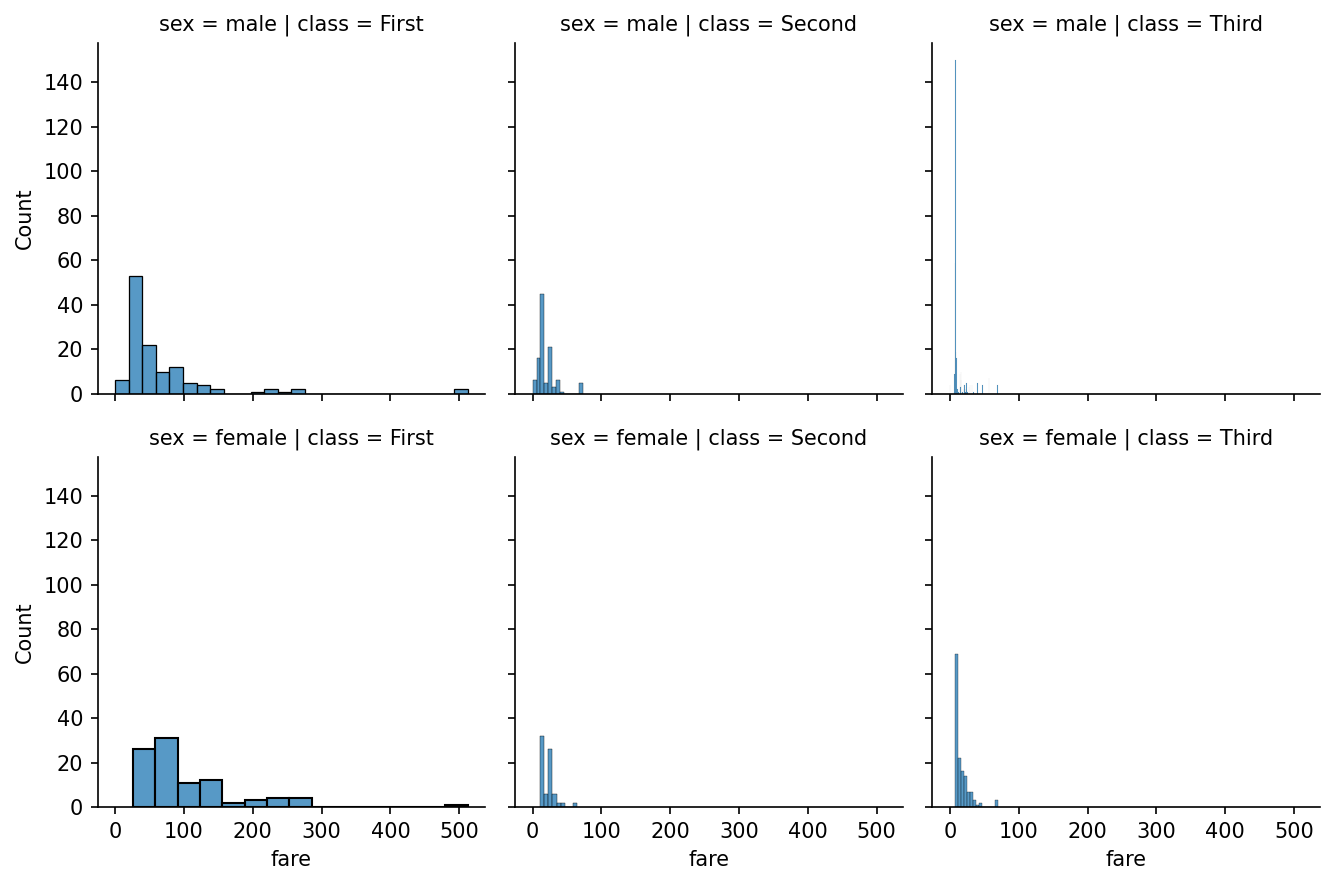

In [59]:
g = sb.FacetGrid(titanic, row='sex', col='class')
g.map(sb.histplot, "fare")
plt.show()

In [60]:
titanic.pivot_table(index=['age_group', 'sex'], columns='alive', values='age', aggfunc=np.mean, margins=True)

alive                    no        yes        All
age_group sex                                    
child     female   6.307692   3.763158   4.796875
          male     5.750000   3.984286   4.747838
teenager  female  15.375000  15.421053  15.413043
          male    16.052632  16.500000  16.095238
adult     female  31.053191  32.887821  32.463054
          male    32.022727  33.500000  32.289894
elder     female        NaN  62.666667  62.666667
          male    66.029412  71.000000  66.552632
All               30.626179  28.343690  29.699118

In [61]:
titanic[
    (titanic.is_old ==1) 
     & (titanic.sex == 'female')]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group,is_old
275,1,1,female,63.0,1,0,77.9583,S,First,woman,False,D,Southampton,yes,False,elder,True
483,1,3,female,63.0,0,0,9.5875,S,Third,woman,False,NaN,Southampton,yes,True,elder,True
829,1,1,female,62.0,0,0,80.0000,NaN,First,woman,False,B,NaN,yes,True,elder,True


In [62]:
titanic[
    (titanic.is_old ==1) 
     & (titanic.sex == 'male')
     & (titanic.alive == 'yes')]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group,is_old
570,1,2,male,62.0,0,0,10.5,S,Second,man,True,NaN,Southampton,yes,True,elder,True
630,1,1,male,80.0,0,0,30.0,S,First,man,True,A,Southampton,yes,True,elder,True


In [63]:
titanic[
    (titanic.is_old ==1) 
     & (titanic.sex == 'male')
     & (titanic.alive == 'no')]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group,is_old
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True,elder,True
54,0,1,male,65.0,0,1,61.9792,C,First,man,True,B,Cherbourg,no,False,elder,True
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True,elder,True
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True,elder,True
170,0,1,male,61.0,0,0,33.5000,S,First,man,True,B,Southampton,no,True,elder,True
252,0,1,male,62.0,0,0,26.5500,S,First,man,True,C,Southampton,no,True,elder,True
280,0,3,male,65.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True,elder,True
326,0,3,male,61.0,0,0,6.2375,S,Third,man,True,NaN,Southampton,no,True,elder,True
438,0,1,male,64.0,1,4,263.0000,S,First,man,True,C,Southampton,no,False,elder,True
456,0,1,male,65.0,0,0,26.5500,S,First,man,True,E,Southampton,no,True,elder,True


In [64]:
titanic.pivot_table('survived', index=['sex', 'is_old'], columns='pclass', aggfunc=np.sum, margins=True, fill_value=0)

pclass           1   2    3  All
sex    is_old                   
female False    89  70   71  230
       True      2   0    1    3
male   False    44  16   47  107
       True      1   1    0    2
All            136  87  119  342

# Import HTML table into a DataFrame

Here will do web scraping with python on
- Oscar dataset


---
## Oscar dataset online

Throughout the history of the Academy Awards, there have been actors and actresses who have received multiple Academy Awards for Best Actor, Best Actress, Best Supporting Actor, or Best Supporting Actress. Here is a webpage with more information: 

https://en.wikipedia.org/wiki/List_of_actors_with_two_or_more_Academy_Awards_in_acting_categories

In [65]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt # we only need pyplot

plt.rcParams['figure.dpi'] = 150 # change resolution

Importing the HTML file from the URL


In [66]:
html_data = pd.read_html('https://en.wikipedia.org/wiki/List_of_actors_with_two_or_more_Academy_Awards_in_acting_categories')

In [67]:
# Check the dataset you imported
print("Data type : ", type(html_data))
print("HTML tables : ", len(html_data))

Data type :  <class 'list'>
HTML tables :  2


In [68]:
# Check the individual tables
html_data[0] # this is the one we want

,Actor/Actress,Best Actor/Actress Awards,Best Supporting Actor/Actress Awards,Total awards,Total nominations
0,Katharine Hepburn †,Morning Glory (1933) Guess Who's Coming to Din...,NaN,4,12
1,Meryl Streep,Sophie's Choice (1982) The Iron Lady (2011),Kramer vs. Kramer (1979),3,21
2,Jack Nicholson,One Flew Over the Cuckoo's Nest (1975) As Good...,Terms of Endearment (1983),3,12
3,Ingrid Bergman †,Gaslight (1944) Anastasia (1956),Murder on the Orient Express (1974),3,7
4,Daniel Day-Lewis,My Left Foot (1989) There Will Be Blood (2007)...,NaN,3,6
5,Frances McDormand,"Fargo (1996) Three Billboards Outside Ebbing, ...",NaN,3,6
6,Walter Brennan †,NaN,Come and Get It (1936) Kentucky (1938) The Wes...,3,4
7,Bette Davis †,Dangerous (1935) Jezebel (1938),NaN,2,10
8,Spencer Tracy †,Captains Courageous (1937) Boys Town (1938),NaN,2,9
9,Denzel Washington,Training Day (2001),Glory (1989),2,9


In [69]:
# Save the table as Pandas Dataframe

awardsDF = pd.DataFrame(html_data[0])
awardsDF.head()

,Actor/Actress,Best Actor/Actress Awards,Best Supporting Actor/Actress Awards,Total awards,Total nominations
0,Katharine Hepburn †,Morning Glory (1933) Guess Who's Coming to Din...,NaN,4,12
1,Meryl Streep,Sophie's Choice (1982) The Iron Lady (2011),Kramer vs. Kramer (1979),3,21
2,Jack Nicholson,One Flew Over the Cuckoo's Nest (1975) As Good...,Terms of Endearment (1983),3,12
3,Ingrid Bergman †,Gaslight (1944) Anastasia (1956),Murder on the Orient Express (1974),3,7
4,Daniel Day-Lewis,My Left Foot (1989) There Will Be Blood (2007)...,NaN,3,6


In [70]:
# Check the statistics for Total awards
awardsDF['Total awards'].describe()

count    45.000000
mean      2.177778
std       0.441531
min       2.000000
25%       2.000000
50%       2.000000
75%       2.000000
max       4.000000
Name: Total awards, dtype: float64

In [71]:
# Check the statistics for Total nominations
awardsDF['Total nominations'].describe()

count    45.000000
mean      5.688889
std       3.482568
min       2.000000
25%       3.000000
50%       5.000000
75%       7.000000
max      21.000000
Name: Total nominations, dtype: float64

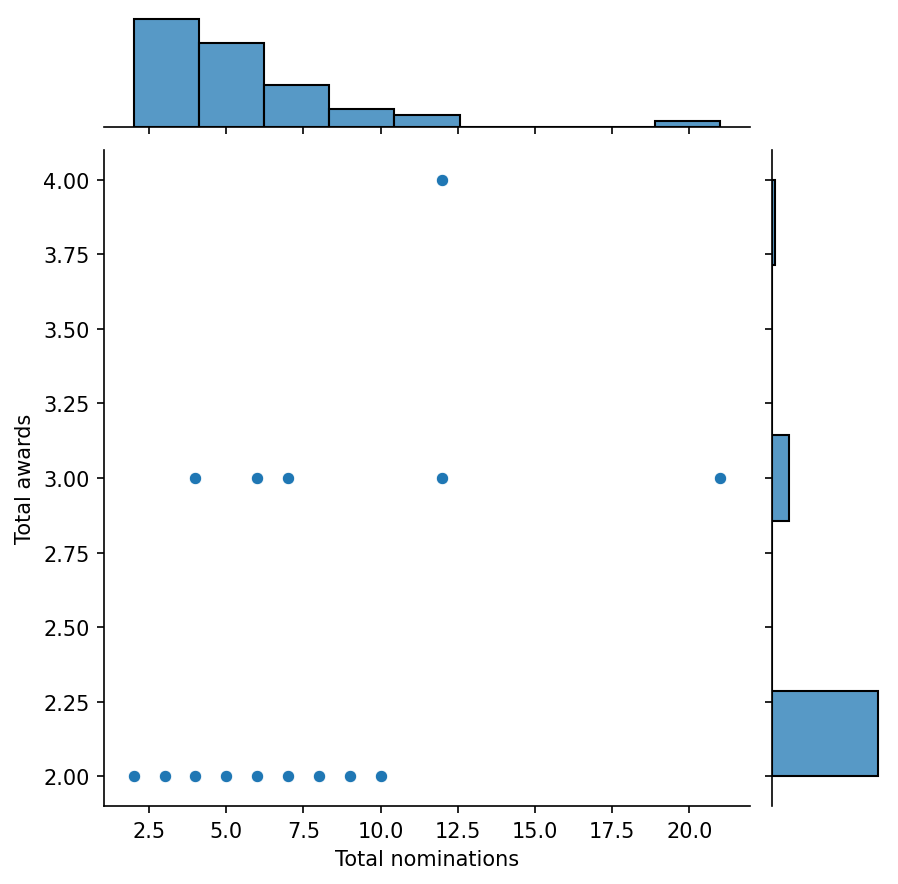

In [72]:
# Check the relationship between nominations and awards
sb.jointplot(x = awardsDF['Total nominations'], y = awardsDF['Total awards'])

# Tips dataset from Seaborn

This is a dataset about the amount of tip that people leave after eating

In [73]:
# Load an example dataset
tips = sb.load_dataset("tips")

In [74]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [75]:
# Look at the tipping percentage by day with seaborn (relative to pre-tipped bill)
tips['tip_pct'] = tips['tip'] / (tips['total_bill'])

In [76]:
tips.describe()

,total_bill,tip,size,tip_pct
count,244.000000,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672,0.160803
std,8.902412,1.383638,0.951100,0.061072
min,3.070000,1.000000,1.000000,0.035638
25%,13.347500,2.000000,2.000000,0.129127
50%,17.795000,2.900000,2.000000,0.154770
75%,24.127500,3.562500,3.000000,0.191475
max,50.810000,10.000000,6.000000,0.710345


---
## Groupby


A `groupby` operation involves some combination of splitting the object, applying a function, and combining the results. This can be used to group large amounts of data and compute operations on these groups.

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html

"groups" is an object of type DataFrameGroupBy. It can be iterated in order to inspect or work with the different groups (each one a DataFrame object) You can also use the get_group method (in this case passing it a 2-sized tuple) to get the corresponding DataFrame group.

We can also just extract the column of interest:

In [77]:
tips.groupby(["sex", "smoker"])[['tip_pct']].mean()

tip_pct
sex    smoker          
Male   Yes     0.152771
       No      0.160669
Female Yes     0.182150
       No      0.156921

The data tells us that female smokers are the best tipper! Tell that to your waiter/waitress friend ;)

---
## Simple data visualization


`barplot()` represents an estimate of central tendency for a numeric variable with the height of each rectangle and provides some indication of the uncertainty around that estimate using error bars. Bar plots include 0 in the quantitative axis range, and they are a good choice when 0 is a meaningful value for the quantitative variable, and you want to make comparisons against it.


https://seaborn.pydata.org/generated/seaborn.barplot.html


<Axes: xlabel='tip_pct', ylabel='day'>

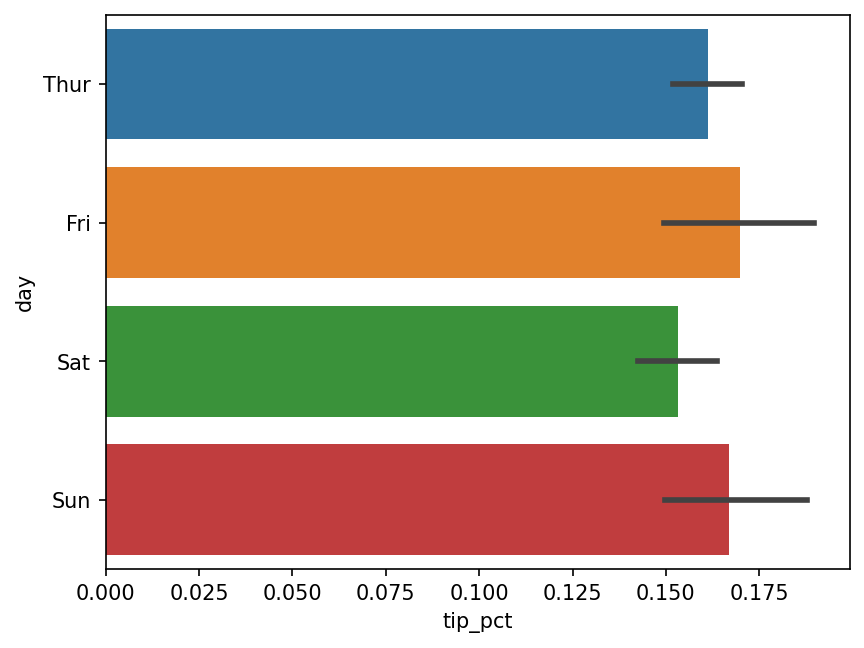

In [78]:
# bar plot of tipping percentage by day with seaborn
# the bars are the average value of tip_pct. 
# The black lines drawn on the bars represent the 95% confidence 
# interval (this can be configured through optional arguments).
sb.barplot(x='tip_pct', y='day', data=tips, orient='h')

<Axes: xlabel='tip_pct', ylabel='day'>

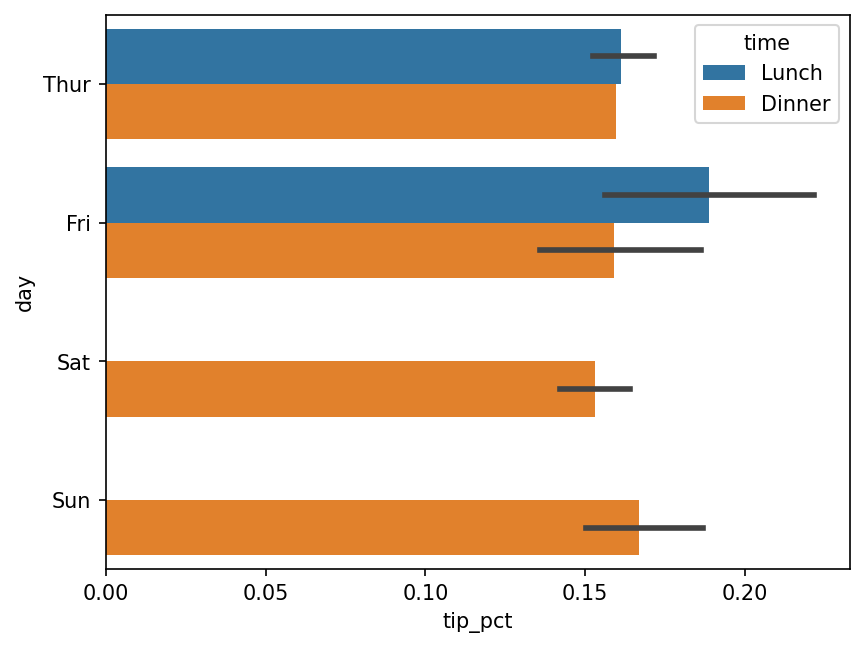

In [79]:
# seaborn.barplot has a hue option that enables us to split by an additional categorical value
sb.barplot(x='tip_pct', y='day', hue='time', data=tips, orient='h')

<Axes: ylabel='Frequency'>

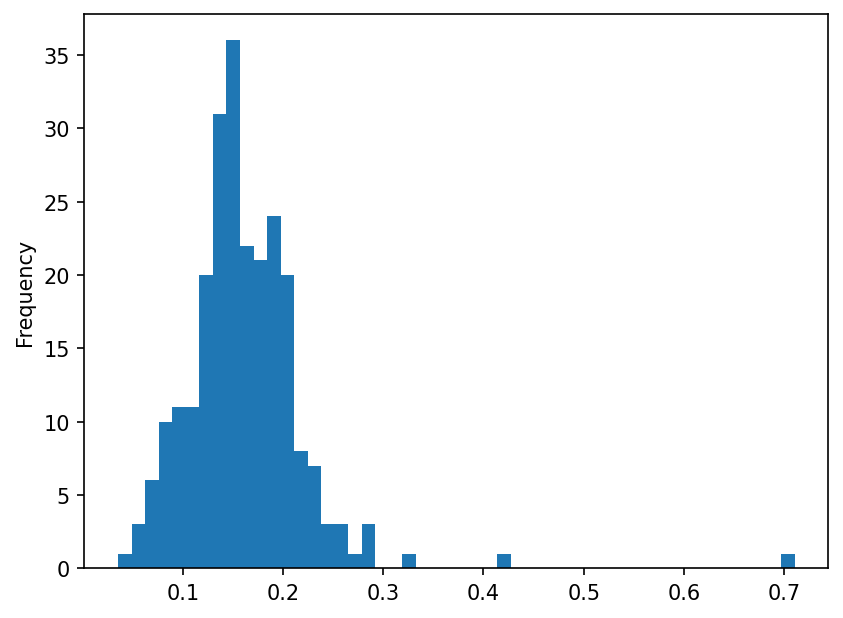

In [80]:
#  histogram of tip percentages of the total bill using the plot.hist()
tips['tip_pct'].plot.hist(bins=50)

<Axes: ylabel='Density'>

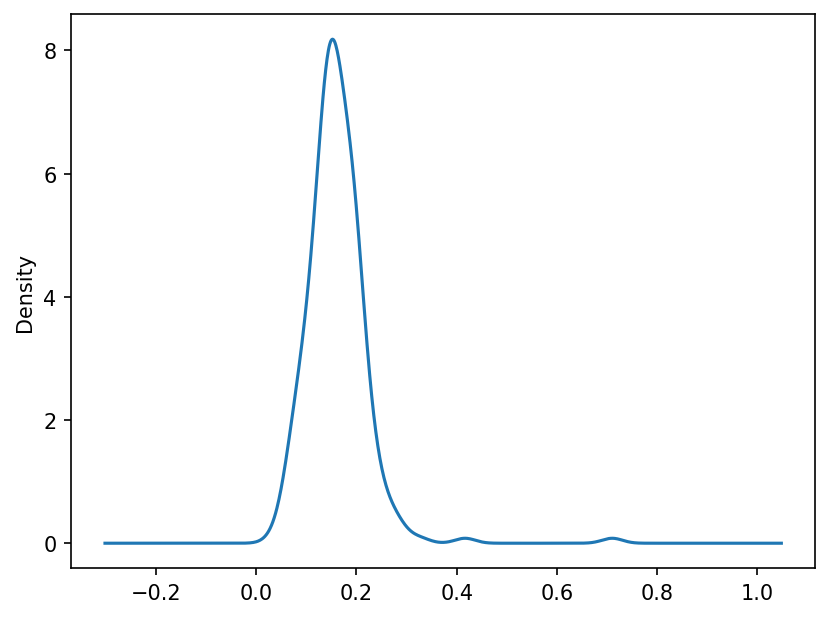

In [81]:
# A related plot type is a density plot, which is formed by computing an 
# estimate of a continuous probability distribution that might have 
# generated the observed data.

tips['tip_pct'].plot.density()

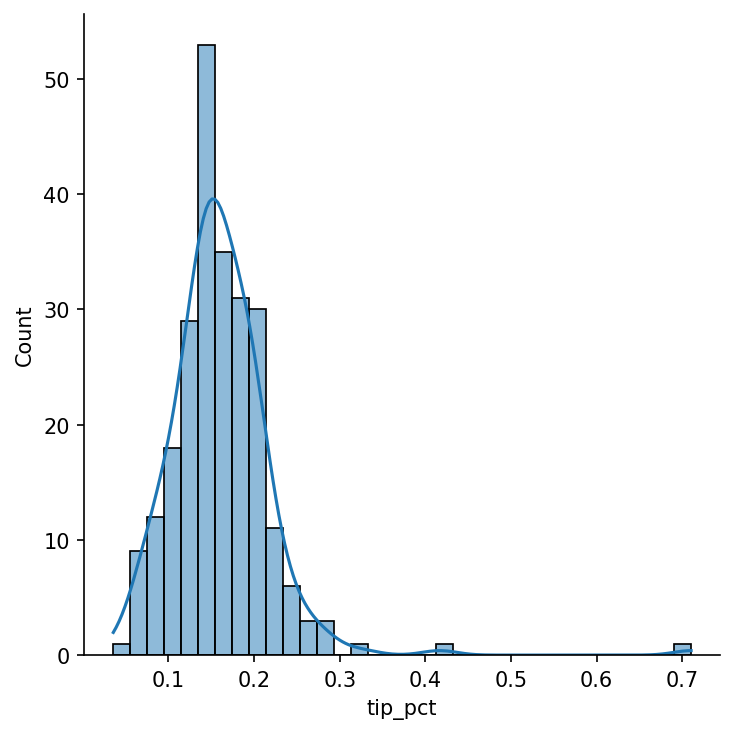

In [82]:
# Seaborn makes histograms and density plots even easier through its displot method, 
# which can plot both a histogram and a continuous density estimate simultaneously. 

sb.displot(tips['tip_pct'], kde=True)

Another powerful tool is `sb.FacetGrid`, a Multi-plot grid for plotting conditional relationships.


https://seaborn.pydata.org/generated/seaborn.FacetGrid.html

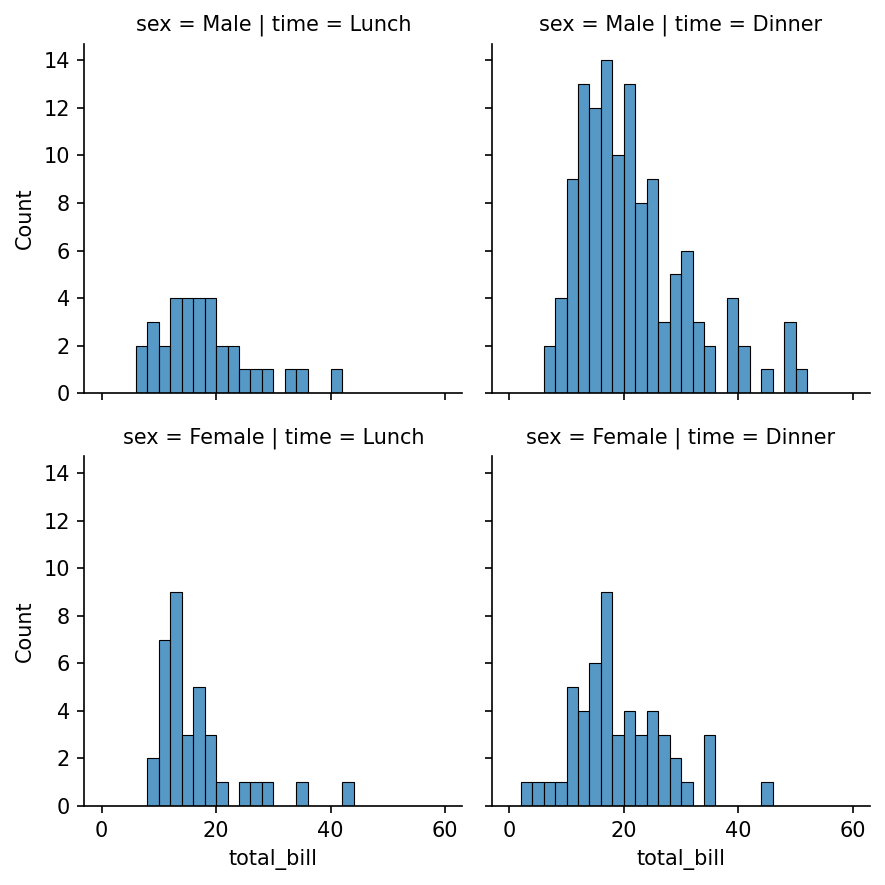

In [83]:
g = sb.FacetGrid(tips, col="time", row="sex")
g.map_dataframe(sb.histplot, x="total_bill", binwidth=2, binrange=(0, 60))

- `sb.FacetGrid()` = Create an Axes (subplot) for each subset of data

- `g.map_dataframe()` = Divide the dataset into subsets and on each Axes, draw the scatter plot using subset of data
corresponding to that Axes


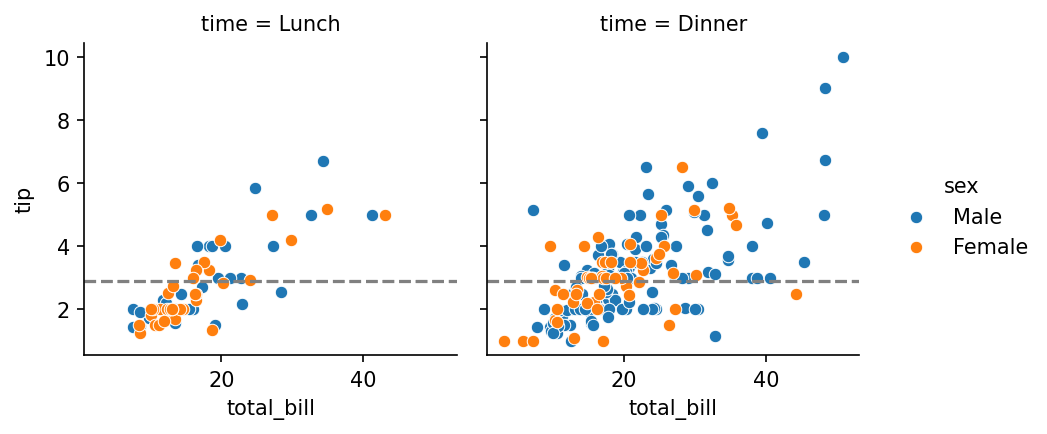

In [84]:
g = sb.FacetGrid(tips, col="time", hue="sex")
g.map_dataframe(sb.scatterplot, x="total_bill", y="tip")
g.add_legend()
g.refline(y=tips["tip"].median())

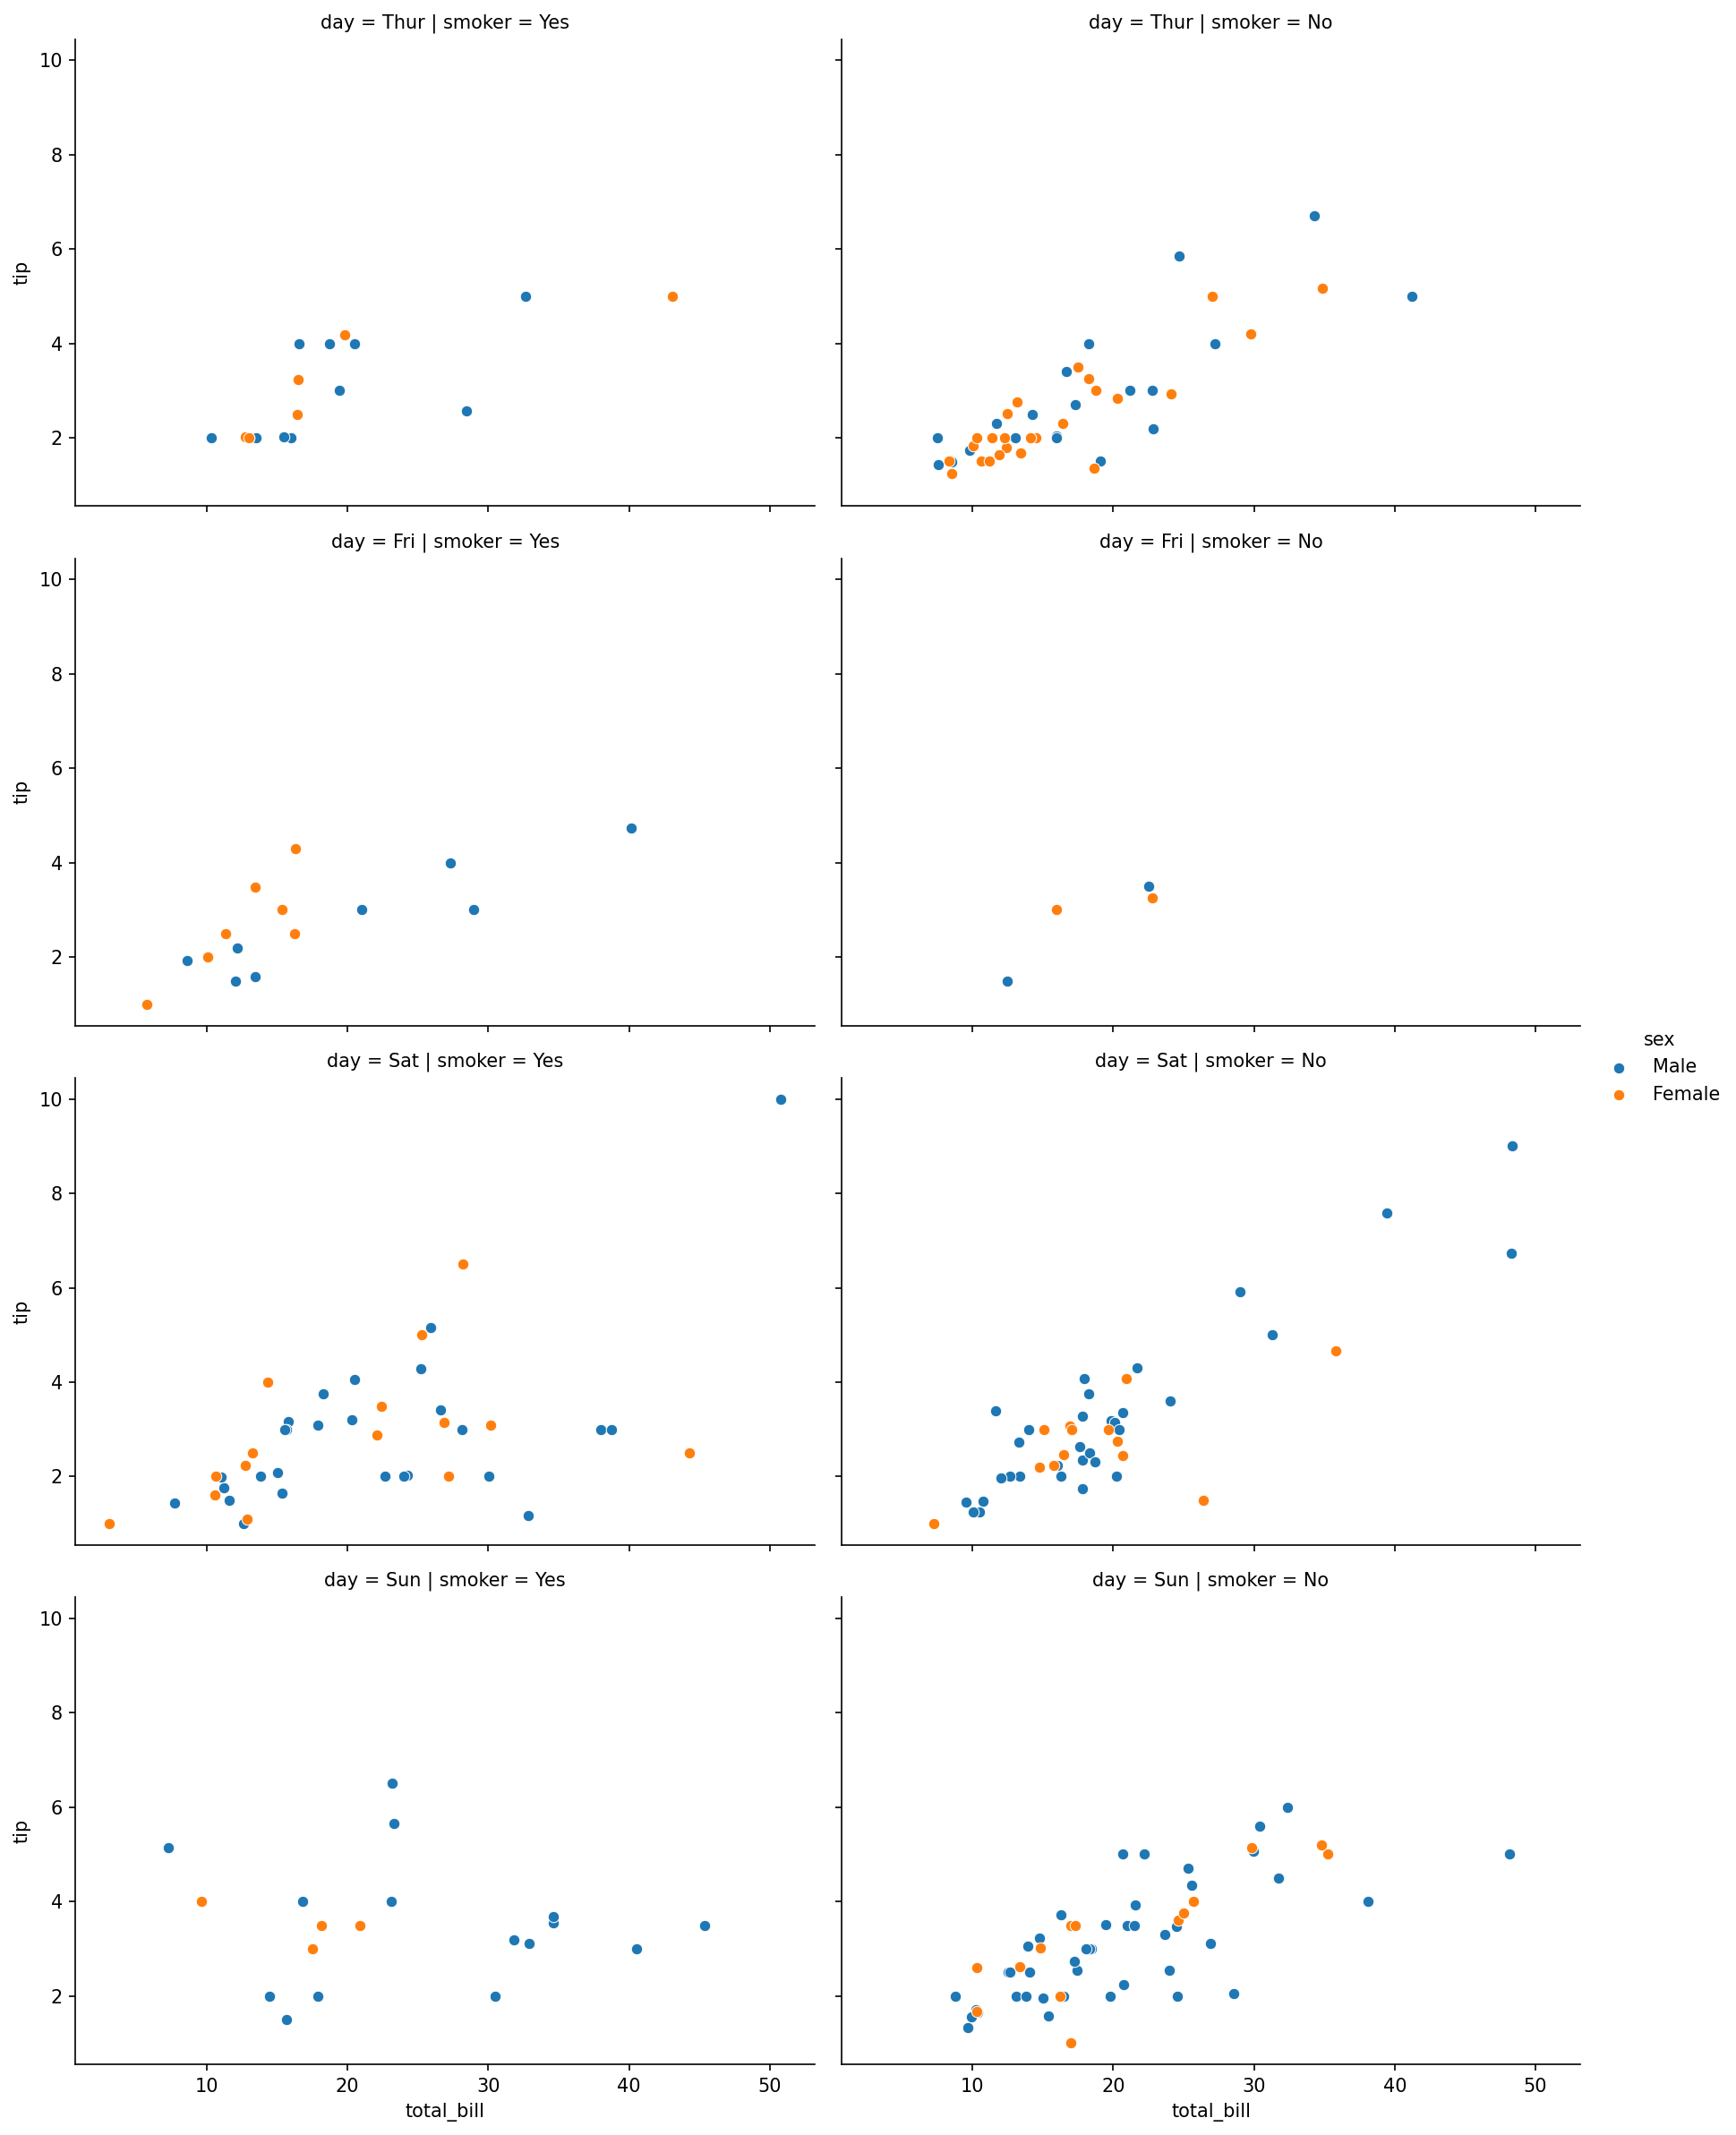

In [85]:
facet_grid = sb.FacetGrid(row='day', col='smoker', hue='sex', data=tips, height=4, aspect=1.5)
facet_grid.map(sb.scatterplot, 'total_bill','tip')
facet_grid.add_legend()

- `sb.FacetGrid()` = Create an Axes (subplot) for each subset of data

- `facet_grid.map()` = Divide the dataset into subsets and on each Axes, draw the scatter plot using subset of data
corresponding to that Axes


---
### Relplot

This plot shows the relationship between five variables ('total_bill', 'tip', 'time', 'smoker', 'size') in the tips dataset using a single call to the seaborn function `relplot()`. Notice how we provided only the names of the variables and their roles in the plot. Unlike when using matplotlib directly, it wasn’t necessary to specify attributes of the plot elements in terms of the color values or marker codes. Behind the scenes, seaborn handled the translation from values in the dataframe to arguments that matplotlib understands. This declarative approach lets you stay focused on the questions that you want to answer, rather than on the details of how to control matplotlib.

https://seaborn.pydata.org/generated/seaborn.relplot.html

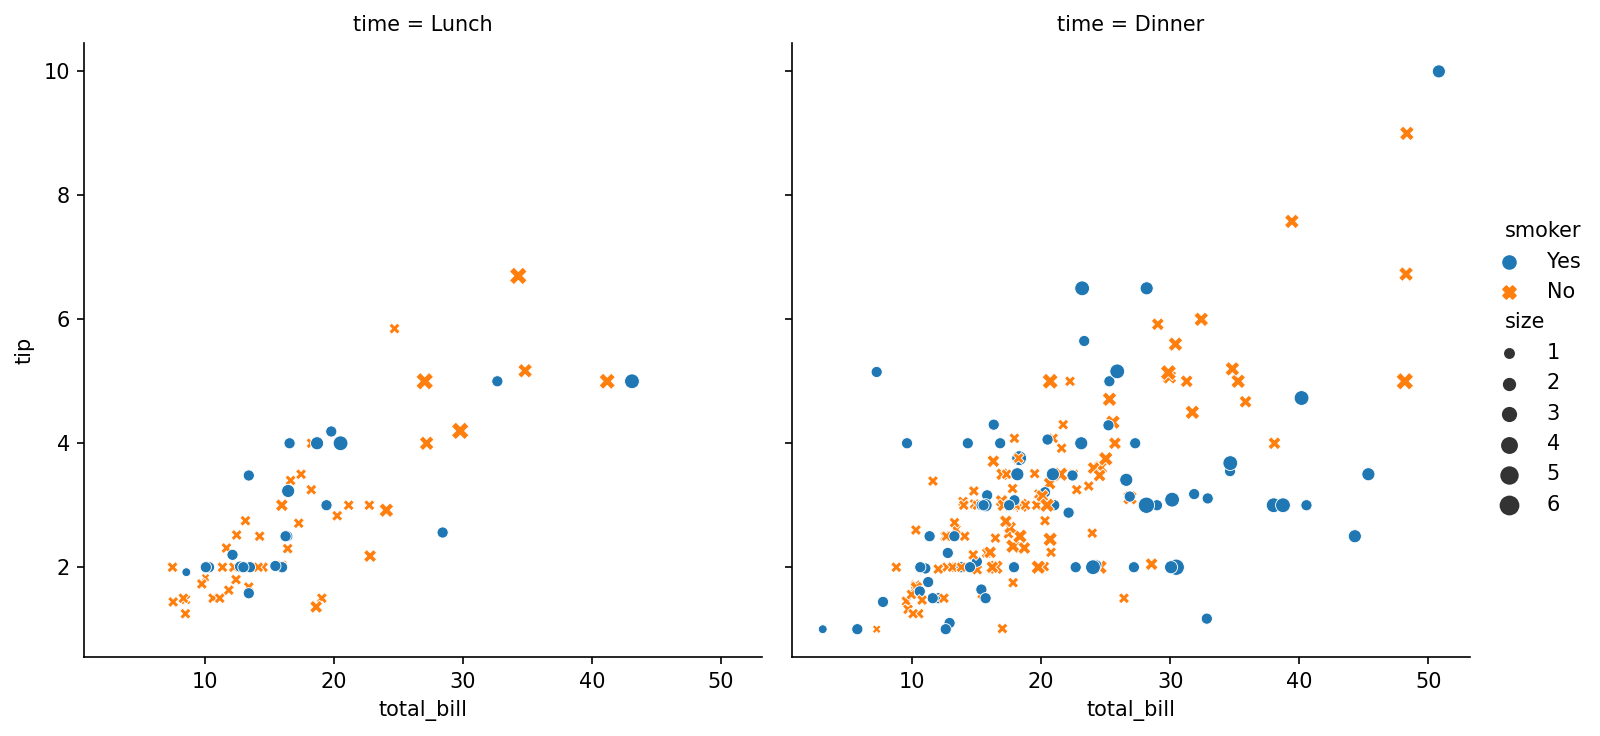

In [86]:
# Create a visualization
sb.relplot(
    data=tips,
    x="total_bill", y="tip", col="time",
    hue="smoker", style="smoker", size="size",
)

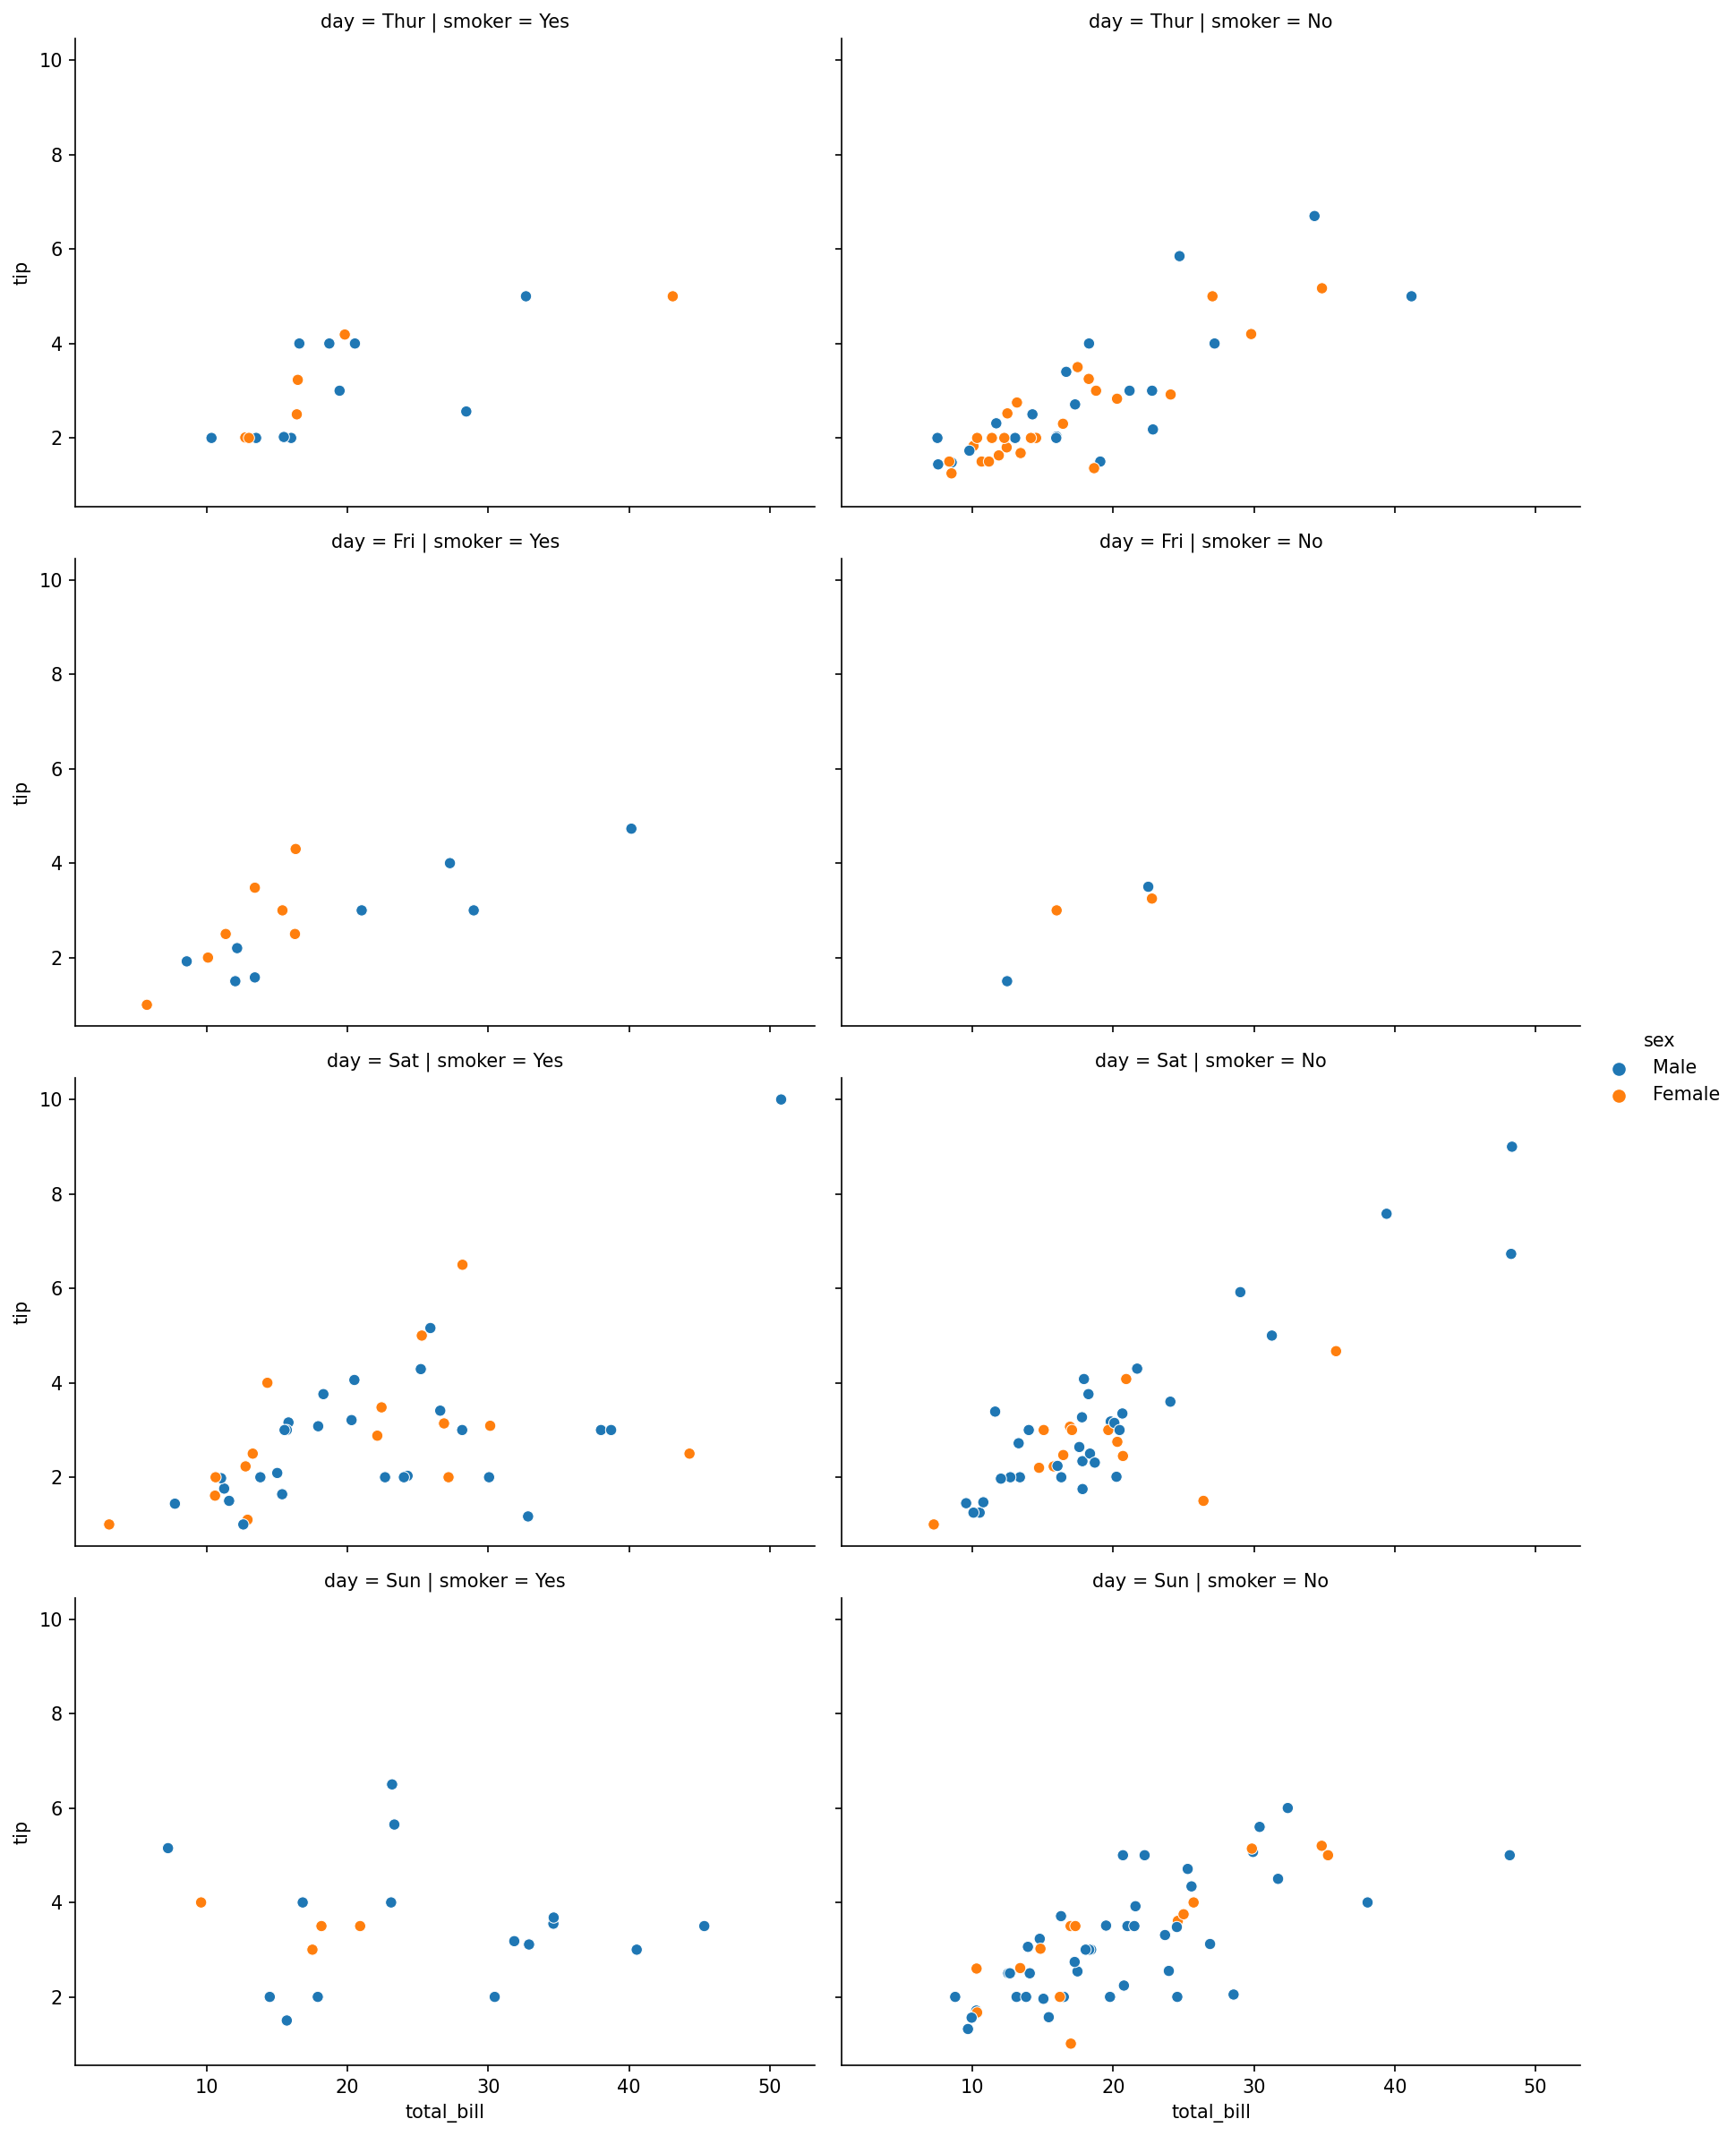

In [87]:
grid = sb.relplot(x='total_bill', y='tip', row='day', col='smoker', hue='sex', data=tips, kind='scatter', height=4, aspect=1.5)

### Distribution

---
Often in statistical data visualization, all you want is to plot histograms and joint distributions of variables. 

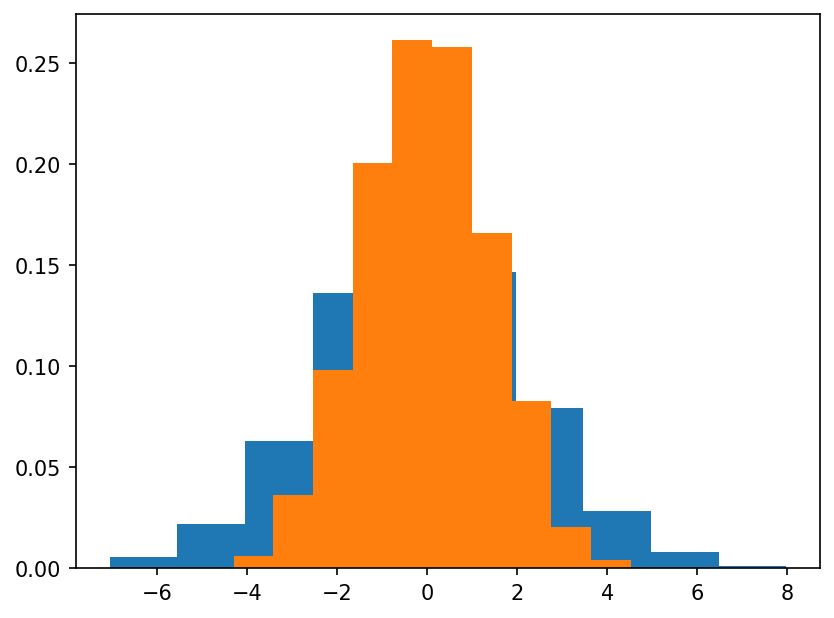

In [88]:
norm_data = np.random.multivariate_normal([0, 0], [[5, 2], [2, 2]], size=2000)
norm_data = pd.DataFrame(norm_data, columns=['x', 'y'])

for col in 'xy':
    plt.hist(norm_data[col], density=True)

Rather than a histogram, we can get a smooth estimate of the distribution using a kernel density estimation, which Seaborn does with sb.kdeplot:



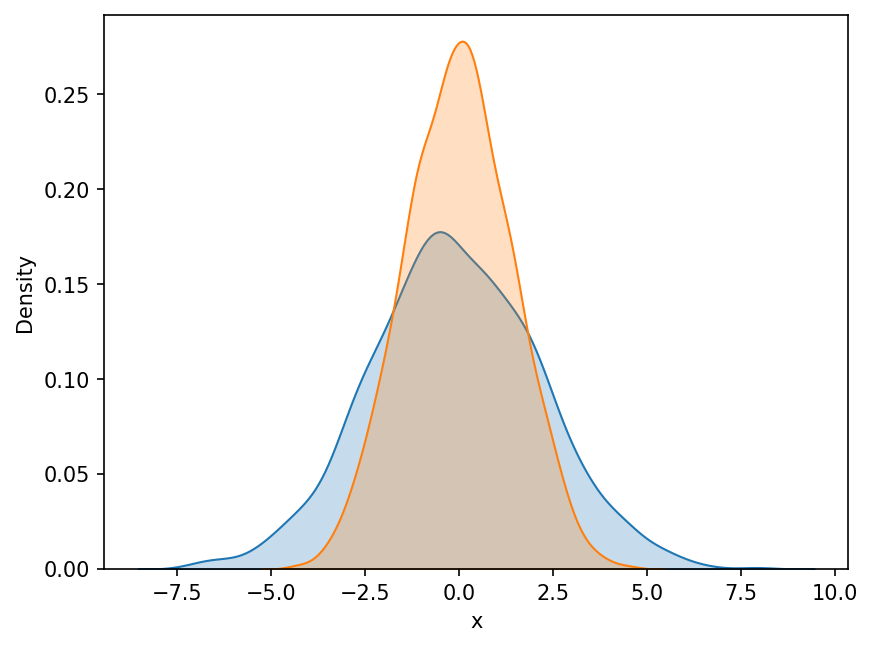

In [89]:
for col in 'xy':
    sb.kdeplot(norm_data[col], fill=True)

Histograms and KDE can be combined using `displot`:

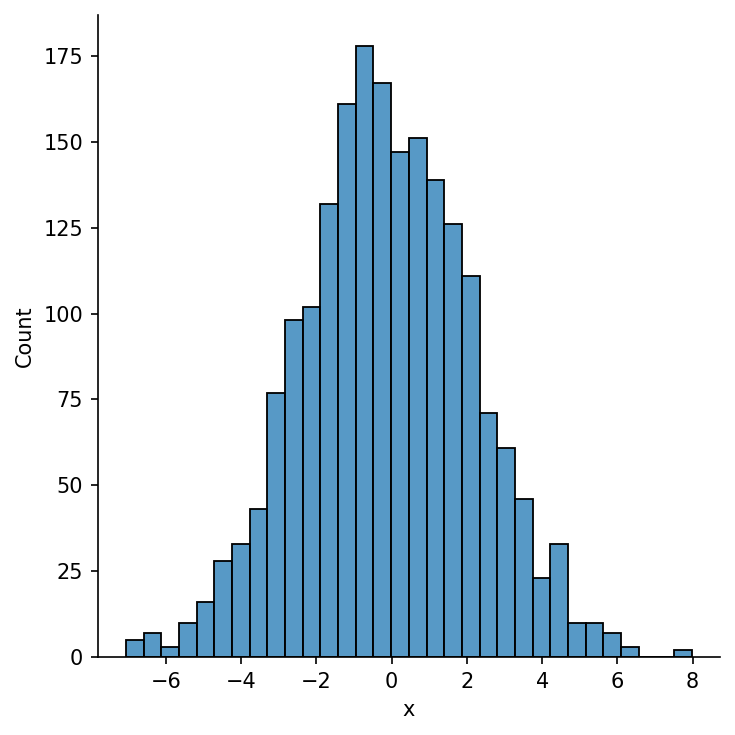

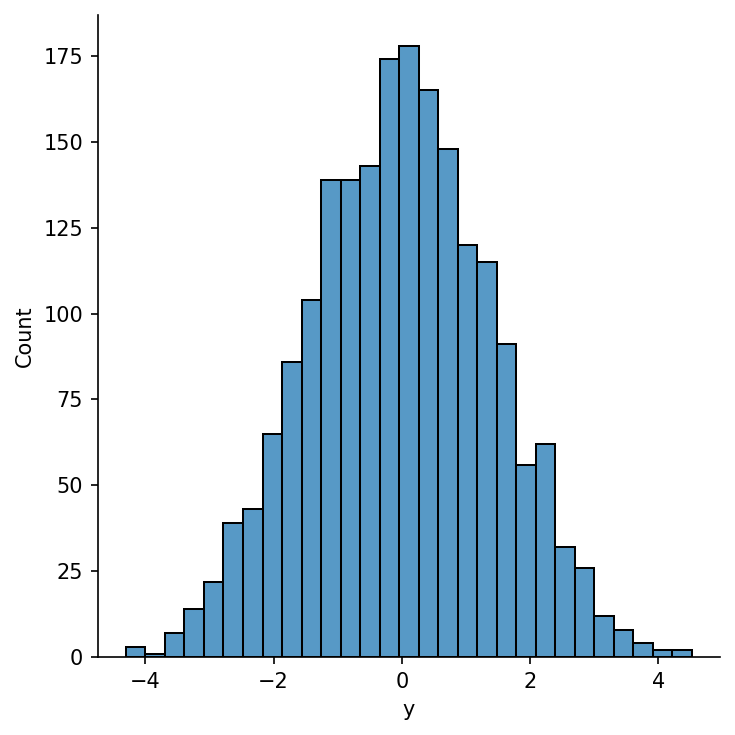

In [90]:
sb.displot(norm_data['x'])
sb.displot(norm_data['y']);

---
If we pass the full two-dimensional dataset to kdeplot, we will get a two-dimensional visualization of the data:

<Axes: xlabel='x', ylabel='y'>

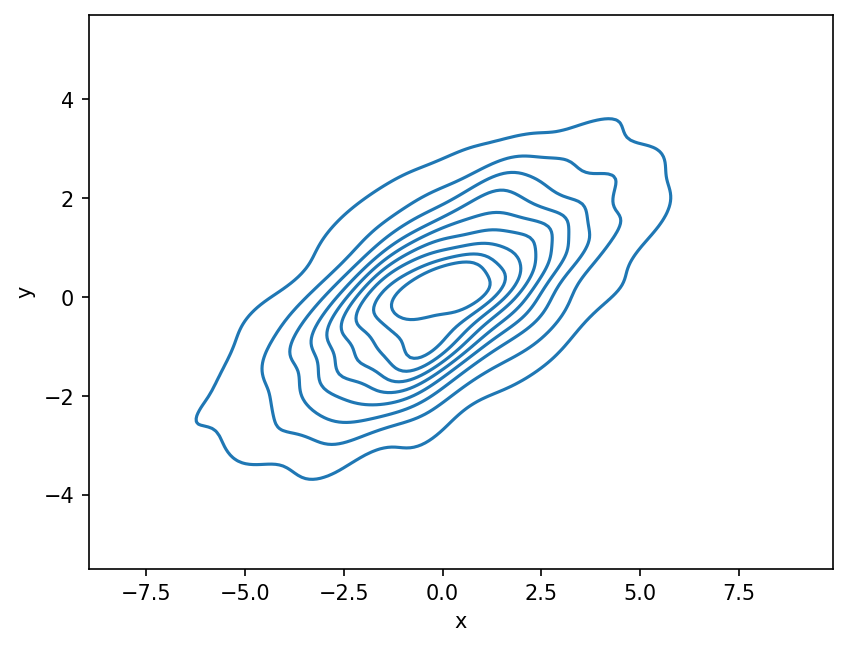

In [91]:
sb.kdeplot(x=norm_data['x'], y=norm_data['y'])


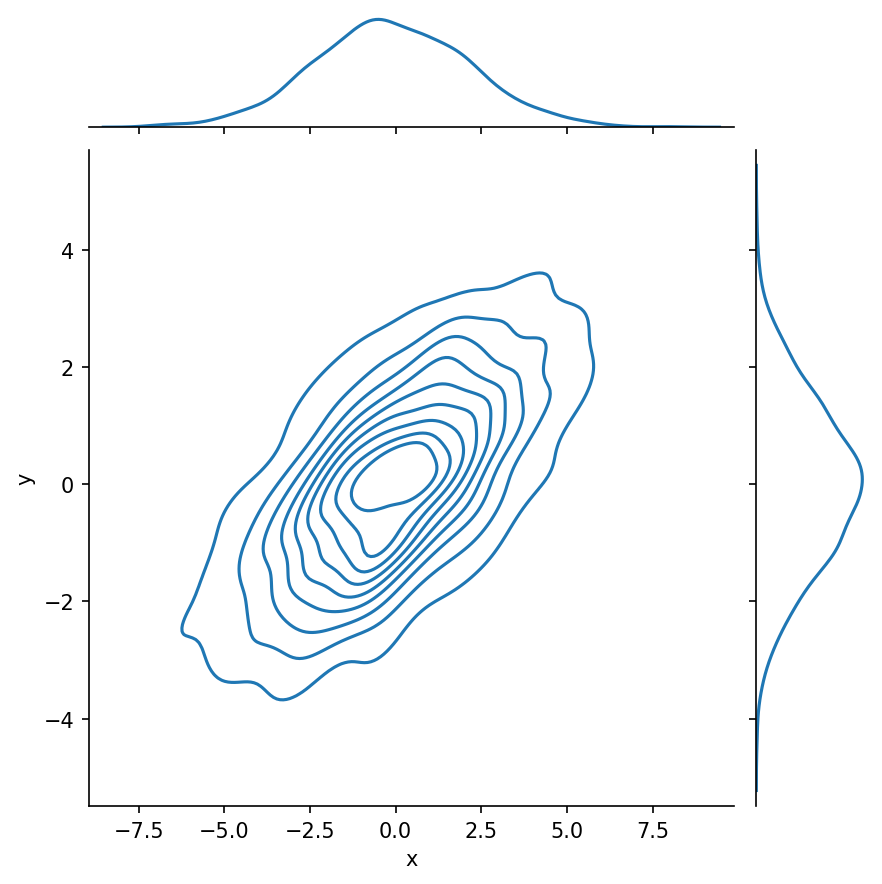

In [92]:
sb.jointplot(data=norm_data, x="x", y="y", kind='kde');